# Transformer 机器翻译（德→英）

基于 WMT16 德英平行语料，实现带有以下特性的 Transformer 序列到序列模型：
- **Pre-Layer Normalization**（Pre-LN）：稳定训练
- **GEGLU 激活函数**：提升前馈网络表达能力
- **Noam 学习率调度**：先预热后衰减
- **BLEU 评估**：计算 BLEU-1 和 BLEU-4 指标

In [1]:
import matplotlib as mpl                # 导入 matplotlib 核心模块，用于图形配置
import matplotlib.pyplot as plt          # 导入 pyplot 子模块，用于绘图
%matplotlib inline                       
# 设置图形在 Jupyter Notebook 中内嵌显示（不弹出新窗口）
import numpy as np                       # 导入 NumPy，提供多维数组和数值计算支持
import os                                # 导入操作系统接口，用于路径/目录操作
import sys                               # 导入 Python 解释器相关模块，用于查看版本信息
from tqdm import tqdm                   # 导入自动适配终端和 Notebook 的进度条工具
import torch                             # 导入 PyTorch 主库，深度学习计算框架
import torch.nn as nn                    # 导入神经网络模块，提供 Module/Linear/Dropout 等
import torch.nn.functional as F         # 导入函数式 API，提供 softmax/cross_entropy 等

# 打印 Python 版本和各依赖库版本，方便环境复现
print(sys.version_info)                  # 输出 Python 版本信息，类型为 sys.version_info
for module in mpl, np, torch:           # 遍历三个核心库
    print(module.__name__, module.__version__)   # 输出库名和版本号（str, str）

# 自动选择计算设备：若有可用 GPU 则使用 cuda:0，否则使用 CPU
# device 类型为 torch.device，后续所有张量和模型都将移至此设备
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)  # 输出当前使用的设备名称，如 'cuda:0' 或 'cpu'

# 固定全局随机种子，确保实验结果可复现
seed = 42                                # 随机种子值，类型为 int
torch.manual_seed(seed)                  # 设置 PyTorch CPU 随机数生成器种子
torch.cuda.manual_seed_all(seed)         # 设置 PyTorch 所有 GPU 随机数生成器种子
np.random.seed(seed)                     # 设置 NumPy 随机数生成器种子


sys.version_info(major=3, minor=14, micro=5, releaselevel='final', serial=0)
matplotlib 3.10.9
numpy 2.4.6
torch 2.12.0+cu132
cuda:0


## 一、数据加载

- 采用 WMT16 的德英平行语料库
- 数据集主页：[WMT16](https://www.statmt.org/wmt16/multimodal-task.html#task1)

In [2]:
from pathlib import Path  # 导入路径处理库，提供跨平台 OOP 风格路径操作
import sentencepiece as spm  # 导入 SentencePiece 库，用于训练/推理 BPE 子词模型
from sacremoses import MosesTokenizer  # 导入 Moses 分词器，用于规则化自然语言分词

data_dir = Path("data/wmt16")             # 数据根目录路径，类型为 Path
sp_prefix = data_dir / "spm_joint_bpe"  # SentencePiece 模型文件前缀，类型为 Path
sp_vocab_size = 20000                 # BPE 词汇表大小，类型为 int
# lang (str): ISO 639-1 语言代码，决定语言特定的分词规则（标点分离、缩写识别、连字符处理等）
src_mt = MosesTokenizer(lang="de")   # 德语 Moses 分词器实例，用于源语言预处理；"de"=德语(Deutsch)
# lang (str): ISO 639-1 语言代码，"en"=英语(English)，决定英语特定的分词规则
tr_mt = MosesTokenizer(lang="en")    # 英语 Moses 分词器实例，用于目标语言预处理


def moses_tokenize_file(in_file, out_file, mt):
    """
    使用 Moses 分词器对文本文件逐行分词，并将结果写入输出文件。

    功能说明:
        读取输入文件每行原始文本，先转为小写，再调用 Moses 分词器进行
        规则化分词（如标点分离），将分词结果按行写入输出文件。空行跳过。

    参数:
        in_file  (str | Path)     : 输入文本文件路径，每行为一条原始句子（UTF-8）
        out_file (str | Path)     : 输出文本文件路径，每行为 Moses 分词后的文本（UTF-8）
        mt       (MosesTokenizer) : Moses 分词器实例，lang 需与文本语言一致

    返回:
        None：函数直接写入文件，无显式返回值
    """
    # 同时打开输入/输出文件，with 语句确保自动关闭
    with open(in_file, "r", encoding="utf8") as fin, open(out_file, "w", encoding="utf8") as fout:
        for line in fin:           # 逐行读取，line 类型为 str（含行尾换行符）
            line = line.strip()    # 去除首尾空白（含 \n），类型仍为 str
            if not line:           # 过滤空行，避免分词空字符串产生噪声
                continue           # 跳过空行，不写入输出
            # 小写化后调用 Moses 分词；return_str=True 返回 str 而非 list[str]
            fout.write(mt.tokenize(line.lower(), return_str=True) + "\n")


# 遍历训练/验证/测试三个数据集划分，分别对德语源文件和英语目标文件进行 Moses 分词
for split in ["train", "val", "test"]:  # split 类型为 str，取值 'train'/'val'/'test'
    moses_tokenize_file(data_dir / f"{split}.de", data_dir / f"{split}_src.cut.txt", src_mt)
    moses_tokenize_file(data_dir / f"{split}.en", data_dir / f"{split}_trg.cut.txt", tr_mt)

# 若 SentencePiece 模型文件不存在则重新训练，避免重复耗时训练
# Path.with_suffix(suffix): 返回将文件后缀替换为 suffix 的新 Path 对象，不修改原路径
#   suffix (str): 新文件后缀，必须以 '.' 开头（如 '.model'）
# Path.exists(): 检查路径是否在文件系统中实际存在，返回 bool
if not (sp_prefix.with_suffix(".model")).exists():  # True=模型文件已存在则跳过训练
    spm.SentencePieceTrainer.train(  # 调用 SentencePiece 静态训练方法
        # 输入德英联合语料（逗号分隔多个文件路径），训练共享词汇表
        input=f"{data_dir / 'train_src.cut.txt'},{data_dir / 'train_trg.cut.txt'}",
        model_prefix=str(sp_prefix),        # 模型保存前缀，生成 .model 和 .vocab 两个文件
        vocab_size=sp_vocab_size,           # 词汇表大小，类型为 int（20000）
        model_type="bpe",                   # 使用字节对编码（Byte Pair Encoding）算法
        character_coverage=1.0,             # 字符覆盖率 1.0 表示覆盖所有字符
        split_by_whitespace=True,           # 先按空白字符分割再做 BPE
        normalization_rule_name="identity", # 不做额外归一化，保留原始文本形式
        hard_vocab_limit=False,             # 允许词汇表略超 vocab_size 上限
    )

# 加载训练好的 SentencePiece 模型，用于后续编码推理
# SentencePieceProcessor 参数说明：
#   model_file (str): 预训练 SentencePiece 模型文件路径（.model 后缀），
#                     由 SentencePieceTrainer.train 生成，决定 BPE 分词规则
sp = spm.SentencePieceProcessor(model_file=str(sp_prefix.with_suffix('.model')))


def sp_encode_file(in_file, out_file, sp):
    """
    使用 SentencePiece 模型对文本文件逐行进行 BPE 子词编码，并写入输出文件。

    功能说明:
        读取输入文件每行（Moses 分词后的文本），调用 SentencePiece 模型将其
        编码为 BPE 子词序列（以空格分隔）。空行写入空行以保持行号对齐。

    参数:
        in_file  (str | Path)             : 输入文件路径，每行为 Moses 分词后的文本（UTF-8）
        out_file (str | Path)             : 输出文件路径，每行为 BPE 子词序列（UTF-8）
        sp       (SentencePieceProcessor) : 已加载的 SentencePiece 模型实例

    返回:
        None：函数直接写入文件，无显式返回值

    示例:
        输入行: "ein mann steht"
        输出行: "▁ein ▁mann ▁steht"  （▁ 为 SentencePiece 词首标记）
    """
    with open(in_file, "r", encoding="utf8") as fin, open(out_file, "w", encoding="utf8") as fout:
        for line in fin:             # 逐行读取，line 类型为 str
            line = line.strip()      # 去除首尾空白，类型为 str
            if not line:             # 保留空行以维持行号对齐
                fout.write("\n")     # 写入空行
                continue             # 跳过后续编码步骤
            # sp.encode 参数说明：
            #   input (str): 待编码的文本字符串（Moses 分词后的单行文本）
            #   out_type (type): str=返回子词字符串列表（含 ▁ 前缀），int=返回 token id 整数列表
            pieces = sp.encode(line, out_type=str)  # list[str]：子词列表，含 ▁ 词首标记
            fout.write(" ".join(pieces) + "\n")  # 子词用空格拼接后写入


# 遍历三个数据集划分，对源/目标语言文件分别进行 BPE 编码
for split in ["train", "val", "test"]:
    sp_encode_file(data_dir / f"{split}_src.cut.txt", data_dir / f"{split}_src.bpe", sp)
    sp_encode_file(data_dir / f"{split}_trg.cut.txt", data_dir / f"{split}_trg.bpe", sp)

print("sentencepiece preprocessing done")  # 打印预处理完成提示


sentencepiece preprocessing done


In [5]:
%%bash
# 使用 Git Bash 的 wc -l 命令统计训练集 BPE 编码文件的总行数
# %%bash：将本 cell 交由 bash 执行（需 Git Bash 已加入系统 PATH）
# wc -l：统计文件行数，每行对应一个已分词的句子
# 输出格式：<行数> <文件路径>
wc -l data/wmt16/train_src.bpe


29000 data/wmt16/train_src.bpe


### 1.1 数据集类（LangPairDataset）

In [4]:
from pathlib import Path                           # 路径操作工具，提供跨平台路径处理
from torch.utils.data import Dataset, DataLoader   # PyTorch 数据集基类和数据加载器


class LangPairDataset(Dataset):
    """
    德英平行语料数据集，支持磁盘缓存以加速重复加载。

    参数:
        mode (str): 数据集划分，可选 train/val/test
        max_length (int): 句对的最大字符长度（超出则过滤）
        overwrite_cache (bool): 是否强制重新生成缓存文件
        data_dir (str): 数据文件根目录
    """

    def __init__(
        self, mode="train", max_length=512, overwrite_cache=False, data_dir="wmt16",
    ):
        """
        初始化语言对数据集：读取 BPE 分词后的源/目标语言文件，
        过滤超长句对，并将结果序列化为 .npy 缓存（后续直接从缓存加载）。

        参数:
            mode            (str)  : 数据集分区，可选 'train' / 'val' / 'test'
            max_length      (int)  : 句对最大字符数，超出则过滤，默认 512
            overwrite_cache (bool) : 是否强制重建缓存（忽略已有缓存），默认 False
            data_dir        (str)  : 数据文件根目录路径，默认 'wmt16'
        """
        self.data_dir = Path(data_dir)  # 将目录路径封装为 Path 对象，方便路径拼接
        # 缓存文件路径：含模式和长度信息，避免重复过滤；类型为 Path
        cache_path = self.data_dir / ".cache" / f"de2en_{mode}_{max_length}.npy"

        # Path.exists(): 检查路径是否存在，返回 bool；不存在则需要生成缓存
        if overwrite_cache or not cache_path.exists():  # 缓存不存在或强制刷新
            # Path.mkdir 参数说明：
            #   parents (bool): True=递归创建所有缺失的父目录（等效于 mkdir -p）
            #   exist_ok (bool): True=目录已存在时不抛出 FileExistsError，静默通过
            cache_path.parent.mkdir(parents=True, exist_ok=True)  # 递归创建缓存目录，已存在则忽略

            # 读取源语言（德语）BPE 编码文件，得到字符串列表
            with open(self.data_dir / f"{mode}_src.bpe", "r", encoding="utf8") as file:
                self.src = file.readlines()  # list[str]，每元素为一行文本（含换行符）

            # 读取目标语言（英语）BPE 编码文件
            with open(self.data_dir / f"{mode}_trg.bpe", "r", encoding="utf8") as file:
                self.trg = file.readlines()  # list[str]

            filtered_src = []  # 过滤后的源语言句子列表
            filtered_trg = []  # 过滤后的目标语言句子列表

            # 按字符长度过滤：两端都不超过 max_length 才保留该句对
            for src, trg in zip(self.src, self.trg):
                if len(src) <= max_length and len(trg) <= max_length:  # 长度过滤
                    filtered_src.append(src.strip())  # strip 去除首尾空白（含换行符）
                    filtered_trg.append(trg.strip())

            filtered_src = np.array(filtered_src)  # 转为 ndarray[str]，便于索引
            filtered_trg = np.array(filtered_trg)  # 转为 ndarray[str]

            # np.save 参数说明：
            #   file (str | Path): 输出文件路径（自动追加 .npy 后缀，若未指定）
            #   arr (array_like): 待保存的数据，此处为包含字符串数组的 dict
            #   allow_pickle (bool): True=允许使用 pickle 序列化非数值类型（如 str、dict）
            np.save(
                cache_path,                                    # 缓存文件路径，类型为 Path
                {"src": filtered_src, "trg": filtered_trg},  # 待保存的 dict，含两个字符串 ndarray
                allow_pickle=True,                            # 允许 pickle 序列化字符串数组
            )
            print(f"save cache to {cache_path}")  # 打印缓存保存路径

        else:
            # np.load 参数说明：
            #   file (str | Path): 待加载的 .npy 文件路径
            #   allow_pickle (bool): True=允许反序列化 pickle 存储的对象（如 dict）
            # .item(): ndarray 方法，将 0 维 ndarray（标量）转换为对应的 Python 原生对象
            #   此处将 np.load 返回的 0-d object array 转换为 Python dict
            cache_dict = np.load(cache_path, allow_pickle=True).item()  # dict：含 'src' 和 'trg' 键
            print(f"load {mode} dataset from {cache_path}")
            filtered_src = cache_dict["src"]  # ndarray[str]：源语言句子数组
            filtered_trg = cache_dict["trg"]  # ndarray[str]：目标语言句子数组

        self.src = filtered_src  # 最终源语言数据，类型为 ndarray[str]
        self.trg = filtered_trg  # 最终目标语言数据，类型为 ndarray[str]

    def __getitem__(self, index):
        """返回第 index 个样本，类型为 (str, str) 元组（源语言, 目标语言）"""
        return self.src[index], self.trg[index]

    def __len__(self):
        """返回数据集样本总数，类型为 int"""
        return len(self.src)  # 源语言数组长度即样本总数


# mode (str): 数据集分区名称，可选 'train'/'val'/'test'，决定读取对应的 BPE 编码文件
train_ds = LangPairDataset("train")  # 构建训练集；"train" 对应 train_src.bpe/train_trg.bpe
# mode (str): 'val' 读取验证集文件（val_src.bpe / val_trg.bpe）
val_ds = LangPairDataset("val")      # 构建验证集，自动生成或加载缓存


save cache to wmt16/.cache/de2en_train_512.npy
save cache to wmt16/.cache/de2en_val_512.npy


In [5]:
# !rm wmt16/.cache -r

In [6]:
# 打印训练集样本总数，验证过滤后剩余样本量
# 源或目标长度超过 max_length(512字符) 的句对已被过滤，数量少于原始文件
len(train_ds)  # 返回 int：过滤后的训练集样本数（约 29000 条）


29000

In [7]:
# 查看训练集最后一个样本的目标语言（英语）字符串长度
len(train_ds[-1][1])  # 返回 int：最后一个样本目标语言的字符数（含空格和子词分割符）


142

In [8]:
# 打印训练集最后一条样本的源语言（德语）和目标语言（英语）BPE 编码文本
# 用于肉眼验证分词结果是否正确（▁ 为 SentencePiece 词首标记）
print("source: {}\ntarget: {}".format(*train_ds[-1]))  # *train_ds[-1] 解包 (src_str, trg_str)


source: ▁ein ▁mann ▁in ▁shorts ▁und ▁hawaii hemd ▁lehnt ▁sich ▁über ▁das ▁geländer ▁eines ▁lot sen boot s ▁, ▁mit ▁nebel ▁und ▁bergen ▁im ▁hintergrund ▁.
target: ▁a ▁man ▁in ▁shorts ▁and ▁a ▁hawaiian ▁shirt ▁leans ▁over ▁the ▁rail ▁of ▁a ▁pilot ▁boat ▁, ▁with ▁fog ▁and ▁mountains ▁in ▁the ▁background ▁.


### 1.2 词汇表与 Tokenizer

这里实现编码器和解码器共享词嵌入的方案

In [9]:
import sentencepiece as spm  # 导入 SentencePiece 子词分割库

# 初始化 4 个特殊词元的映射字典（特殊 token → 整数索引）
# 这些特殊 token 不来自 BPE 词汇表，需手动预定义
word2idx = {
    "[PAD]": 0,   # 填充词元：用于对齐短句，在注意力计算中会被 mask 掉
    "[BOS]": 1,   # 句子起始词元：Decoder 输入序列的第一个 token
    "[UNK]": 2,   # 未知词元：OOV（词表外）词映射到此索引
    "[EOS]": 3,   # 句子终止词元：Decoder 输出序列的结束标志
}
# 反向映射：整数索引 → 词元字符串（用于解码还原文本），类型为 dict[int, str]
idx2word = {value: key for key, value in word2idx.items()}
index = len(idx2word)  # 下一个可用索引值（初始为 4），类型为 int

# 加载预训练的联合 BPE 词汇表（德英共享 20000 个子词）
# SentencePieceProcessor 参数说明：
#   model_file (str): 预训练 SentencePiece 模型文件的路径（.model 后缀），
#                     本处加载德英联合 BPE 模型，用于遍历词汇表构建 word2idx
sp = spm.SentencePieceProcessor(model_file="wmt16/spm_joint_bpe.model")

# 遍历 BPE 词汇表中所有子词，加入自定义 word2idx/idx2word
for i in tqdm(range(sp.get_piece_size())):  # get_piece_size() 返回 int（约 20000）
    token = sp.id_to_piece(i)               # 根据 SP 内部 id 获取子词字符串，类型为 str
    # 跳过已存在的特殊词元及 SP 内置符号，避免重复或冲突
    if token in word2idx or token in {"<unk>", "<s>", "</s>"}:
        continue
    word2idx[token] = index  # 将子词加入 词元→索引 映射
    idx2word[index] = token  # 将索引加入 索引→词元 映射
    index += 1               # 索引自增，为下一个子词准备位置

vocab_size = len(word2idx)                    # 最终词汇表大小，类型为 int（约 20001）
print("vocab_size: {}".format(vocab_size))    # 打印词汇表大小（4个特殊词元 + BPE子词）



  0%|          | 0/20000 [00:00<?, ?it/s]


100%|██████████| 20000/20000 [00:00<00:00, 729209.56it/s]

vocab_size: 20001


In [10]:
# 打印 词元→索引 映射的大小，验证词汇表是否构建完整
len(word2idx)  # 返回 int：4个特殊词元 + BPE子词，预期约 20001


20001

In [11]:
# 打印 索引→词元 映射的大小，验证与 word2idx 双向映射完整性
len(idx2word)  # 返回 int：应与 word2idx 大小完全相同（20001）


20001

In [12]:
class Tokenizer:
    """
    文本词元化器：负责文本与 token id 之间的双向转换。

    支持批量编码时自动添加 BOS/EOS 特殊词元，并对批量文本进行统一长度 PAD 填充。
    解码时支持自动去除特殊词元，还原为可读文本或词元列表。
    """

    def __init__(self, word2idx, idx2word, max_length=512, pad_idx=0, bos_idx=1, eos_idx=3, unk_idx=2):
        """
        初始化词元化器，设置词汇映射表和各特殊词元的索引。

        参数:
            word2idx   (dict[str, int]) : 词元字符串 → 整数索引 的正向映射字典
            idx2word   (dict[int, str]) : 整数索引 → 词元字符串 的反向映射字典
            max_length (int)            : 单条样本最大 token 数（含特殊词元），超出截断，默认 512
            pad_idx    (int)            : 填充词元 [PAD] 的索引，默认 0
            bos_idx    (int)            : 起始词元 [BOS] 的索引，默认 1
            eos_idx    (int)            : 结束词元 [EOS] 的索引，默认 3
            unk_idx    (int)            : 未知词元 [UNK] 的索引，默认 2
        """
        self.word2idx = word2idx      # 词元→索引映射，类型为 dict[str, int]
        self.idx2word = idx2word      # 索引→词元映射，类型为 dict[int, str]
        self.max_length = max_length  # 最大序列长度（含 BOS/EOS），类型为 int
        self.pad_idx = pad_idx        # PAD 填充词元索引，类型为 int
        self.bos_idx = bos_idx        # BOS 起始词元索引，类型为 int
        self.eos_idx = eos_idx        # EOS 结束词元索引，类型为 int
        self.unk_idx = unk_idx        # UNK 未知词元索引，类型为 int

    def encode(self, text_list, padding_first=False, add_bos=True, add_eos=True, return_mask=False):
        """
        将批量分词后的文本转换为 token id 张量，并进行长度对齐 PAD 填充。

        参数:
            text_list     (list[list[str]]): 批量文本，每条已分词为词元列表
            padding_first (bool)           : True 时在序列头部补 PAD（右对齐），False 时尾部补 PAD，默认 False
            add_bos       (bool)           : 是否在序列头部插入 BOS 词元，默认 True
            add_eos       (bool)           : 是否在序列尾部追加 EOS 词元，默认 True
            return_mask   (bool)           : 是否同时返回 PAD 掩码张量，默认 False

        返回:
            return_mask=False 时: Tensor[batch, seq_len]，token id 张量，dtype=int64
            return_mask=True  时: (Tensor[batch, seq_len], Tensor[batch, seq_len])
                                   第一项为 token id 张量；
                                   第二项为 PAD 掩码（PAD 位置=1，非 PAD=0），dtype=int64
        """
        # 计算本批次的统一序列长度：不超过全局 max_length，但也不超过最长样本所需长度
        max_length = min(self.max_length, add_eos + add_bos + max([len(text) for text in text_list]))
        indices_list = []  # 存储编码后各样本的 token id 列表，类型为 list[list[int]]
        for text in text_list:  # text 为单条词元列表，类型为 list[str]
            # 查表编码：有效 token 数 = max_length - BOS(0/1) - EOS(0/1)，超长部分截断
            # 词表外词元映射为 unk_idx；返回 list[int]
            indices = [self.word2idx.get(word, self.unk_idx) for word in text[:max_length - add_bos - add_eos]]
            if add_bos:
                indices = [self.bos_idx] + indices   # 头部插入 BOS 索引
            if add_eos:
                indices = indices + [self.eos_idx]   # 尾部追加 EOS 索引
            if padding_first:
                # 头部填充：短序列左侧补 PAD，使序列右对齐
                indices = [self.pad_idx] * (max_length - len(indices)) + indices
            else:
                # 尾部填充：短序列右侧补 PAD，使序列左对齐（最常用方案）
                indices = indices + [self.pad_idx] * (max_length - len(indices))
            indices_list.append(indices)  # 将当前样本的索引列表追加到批量列表
        # 转换为 PyTorch 长整型张量，形状为 [batch_size, max_length]
        input_ids = torch.tensor(indices_list)  # Tensor[batch, seq_len]，dtype=int64
        # PAD 掩码：PAD 位置=1，非 PAD=0；用于损失计算中忽略填充位置
        masks = (input_ids == self.pad_idx).to(dtype=torch.int64)  # Tensor[batch, seq_len]
        return input_ids if not return_mask else (input_ids, masks)

    def decode(self, indices_list, remove_bos=True, remove_eos=True, remove_pad=True, split=False):
        """
        将 token id 批量解码还原为可读文本或词元列表。

        参数:
            indices_list (list[list[int]]): 批量 token id 序列
            remove_bos   (bool)           : 是否跳过 BOS 词元，默认 True
            remove_eos   (bool)           : 遇到 EOS 时是否立即停止解码（截断后续 token），默认 True
            remove_pad   (bool)           : 遇到 PAD 时是否立即停止解码，默认 True
            split        (bool)           : False 时返回拼接字符串，True 时返回词元列表，默认 False

        返回:
            split=False 时: list[str]         每元素为空格拼接的句子字符串
            split=True  时: list[list[str]]   每元素为词元列表（用于 BLEU 评估等场景）
        """
        text_list = []   # 存储所有解码结果，类型为 list[str] 或 list[list[str]]
        for indices in indices_list:  # indices 为单条 token id 列表，类型为 list[int]
            text = []   # 当前句子的词元列表，类型为 list[str]
            for index in indices:  # index 为单个 token id，类型为 int
                word = self.idx2word.get(index, "[UNK]")  # 索引→词元；不在表中返回 "[UNK]"
                if remove_bos and word == "[BOS]":  # 跳过 BOS 词元（不加入输出）
                    continue
                if remove_eos and word == "[EOS]":  # 遇 EOS 立即截断，忽略后续 token
                    break
                if remove_pad and word == "[PAD]":  # 遇 PAD 立即截断，忽略填充部分
                    break
                text.append(word)  # 将有效词元追加到当前句子列表
            # split=False：空格拼接为句子字符串；split=True：返回词元列表
            text_list.append(" ".join(text) if not split else text)
        return text_list  # 返回 list[str] 或 list[list[str]]


# 实例化分词器，使用之前构建的 word2idx/idx2word 映射
tokenizer = Tokenizer(word2idx=word2idx, idx2word=idx2word)

# 测试用原始输入（已按空格分词的词元列表），类型为 list[list[str]]
raw_text = [
    "two young , white males are outside near many bushes .".split(),
    "several men in hard hats are operating a giant pulley system .".split(),
    "a bunch of elderly women play their clarin@@ ets together as they read off sheet music .".split()
]
# tokenizer.encode 参数说明：
#   text_list (list[list[str]]): 批量分词文本
#   padding_first (bool): False=尾部补PAD（左对齐），True=头部补PAD（右对齐）
#   add_bos (bool): True=在序列头部插入 [BOS] 词元
#   add_eos (bool): True=在序列尾部追加 [EOS] 词元
# 返回 Tensor[3, max_len]，批次内按最长序列对齐
indices = tokenizer.encode(raw_text, padding_first=False, add_bos=True, add_eos=True)
# tokenizer.decode 参数说明：
#   indices_list: token id 批量列表
#   remove_bos (bool): False=保留 [BOS] 词元（不跳过）
#   remove_eos (bool): False=遇 [EOS] 不截断，继续解码后续 token
#   remove_pad (bool): False=遇 [PAD] 不截断，保留所有填充位置
# 不去除任何特殊词元，验证编解码完整性；返回 list[str]
decode_text = tokenizer.decode(indices.tolist(), remove_bos=False, remove_eos=False, remove_pad=False)
print("raw text")      # 打印原始词元列表
for raw in raw_text:
    print(raw)
print("indices")       # 打印编码后的 token id 张量（每行对应一条样本）
for index in indices:
    print(index)
print("decode text")   # 打印解码还原的文本，验证与原始输入的对应关系
for decode in decode_text:
    print(decode)


raw text
['two', 'young', ',', 'white', 'males', 'are', 'outside', 'near', 'many', 'bushes', '.']
['several', 'men', 'in', 'hard', 'hats', 'are', 'operating', 'a', 'giant', 'pulley', 'system', '.']
['a', 'bunch', 'of', 'elderly', 'women', 'play', 'their', 'clarin@@', 'ets', 'together', 'as', 'they', 'read', 'off', 'sheet', 'music', '.']
indices
tensor([    1,     2,     2, 19958, 13080,     2,   613,     2,     2,     2,
            2, 19951,     3,     0,     0,     0,     0,     0,     0])
tensor([    1,     2,   287,     4,     2, 14793,   613,     2, 19936,     2,
            2,     2, 19951,     3,     0,     0,     0,     0,     0])
tensor([    1, 19936,     2,  2336,     2,     2, 18313,     2,     2,  7603,
            2,    80,     2,     2,  3992,     2,     2, 19951,     3])
decode text
[BOS] [UNK] [UNK] , white [UNK] are [UNK] [UNK] [UNK] [UNK] . [EOS] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]
[BOS] [UNK] men in [UNK] hats are [UNK] a [UNK] [UNK] [UNK] . [EOS] [PAD] [PAD] [PAD] [

In [13]:
# 验证训练集第一个样本的源/目标语言字符串长度
for i, j in train_ds:     # i: 源语言字符串 (str), j: 目标语言字符串 (str)
    print(len(i))          # 打印源语言字符串的字符数（含空格和子词符）
    print(len(j))          # 打印目标语言字符串的字符数
    break                  # 只查看第一个样本后立即退出


79
65


### 1.3 Transformer 批量采样器（TransformerBatchSampler）

句子按照序列长度相近的原则分配到同一批次，每批次约含 28000 个源 token 和 28000 个目标 token。

In [14]:
class SampleInfo:
    """
    单条样本的元信息容器，记录样本索引和源/目标语言长度，供 TokenBatchCreator 装箱使用。
    """

    def __init__(self, i, lens):
        """
        初始化样本信息，计算源/目标长度及两者最大值（用于控制批次大小）。

        参数:
            i    (int)       : 样本在数据集中的全局索引
            lens (list[int]) : [src_len, trg_len]，源语言和目标语言字符串的字符数
        """
        self.i = i                            # 样本索引，类型为 int
        # +1 是为了给 BOS/EOS 等特殊词元预留位置
        # max_len 用于 TokenBatchCreator 估算 '最大长度 x 样本数' 是否超出批次容量
        self.max_len = max(lens[0], lens[1]) + 1  # 源/目标中较长者 +1，类型为 int
        self.src_len = lens[0] + 1               # 源语言长度 +1（含特殊词元），类型为 int
        self.trg_len = lens[1] + 1               # 目标语言长度 +1（含特殊词元），类型为 int


class TokenBatchCreator:
    """
    基于 token 数量上限的动态批量构建器。

    每次调用 append 传入一条样本信息，当 '当前批内最大序列长度 × (样本数+1)'
    超出 batch_size 时，返回已积累的批次并开启新批次；否则继续累积。
    这保证每个批次的 token 总量约等于 batch_size，而非固定样本数。
    """

    def __init__(self, batch_size):
        """
        初始化批量构建器。

        参数:
            batch_size (int): 每个批次允许的最大 token 总量（= 最大序列长度 × 样本数）
        """
        self._batch = []        # 当前正在累积的批次，类型为 list[SampleInfo]
        self.max_len = -1       # 当前批次内的最大序列长度（初始为 -1），类型为 int
        self._batch_size = batch_size  # 批次容量上限（如 4096），类型为 int

    def append(self, info: SampleInfo):
        """
        尝试将新样本加入当前批次，若超出容量则返回旧批次并开启新批次。

        参数:
            info (SampleInfo): 待加入的样本元信息

        返回:
            list[SampleInfo] | None:
                加入新样本后若超出容量，返回已积累的旧批次（list[SampleInfo]）；
                否则返回 None（表示继续累积）
        """
        cur_len = info.max_len                   # 当前新样本的最大序列长度，类型为 int
        max_len = max(self.max_len, cur_len)     # 加入新样本后批次内的最大长度，类型为 int
        # 检查：若将该样本加入后，token 总量超出批次容量上限
        # 公式：最大序列长度 × 新批次样本数 = max_len × (len(_batch) + 1)
        if max_len * (len(self._batch) + 1) > self._batch_size:
            # 将旧批次保存到 result，_batch 清空准备接收新批次的第一条样本
            self._batch, result = [], self._batch  # result 为待返回的旧批次
            self._batch.append(info)               # 新批次的首条样本入列
            self.max_len = cur_len                 # 重置最大长度为当前样本长度
            return result                          # 返回旧批次，供外部收集
        else:
            self.max_len = max_len                 # 更新当前批次的最大长度
            self._batch.append(info)               # 将样本追加到当前批次
            return None                            # 继续累积，暂不返回批次

    @property
    def batch(self):
        """
        返回当前未满的批次（训练结束时获取最后一个不完整批次）。

        返回:
            list[SampleInfo]: 当前积累但尚未返回的样本列表
        """
        return self._batch  # list[SampleInfo]，可能为空列表


In [15]:
from torch.utils.data import BatchSampler  # 导入批量采样器基类
import numpy as np                           # 导入 NumPy，用于随机数控制


class TransformerBatchSampler(BatchSampler):
    """
    Transformer 专用动态批量采样器，按序列长度相近原则将样本分组，
    保证每批次的 token 总量（最大序列长度 × 样本数）约等于 batch_size。

    与固定样本数的批采样器相比，该采样器减少了 PAD 填充浪费，
    更充分地利用显存，与 Transformer 原论文的训练方案一致。
    """

    def __init__(self,
                 dataset,
                 batch_size,
                 shuffle_batch=False,
                 clip_last_batch=False,
                 seed=0):
        """
        初始化采样器，预计算所有样本的长度信息。

        参数:
            dataset        (Dataset): 数据集实例，需支持 enumerate 和 len
            batch_size     (int)    : 每批次 token 总量上限（= 最大序列长度 × 样本数）
            shuffle_batch  (bool)   : 是否对生成的批次顺序进行随机打乱，默认 False
            clip_last_batch(bool)   : 是否丢弃最后一个不满的批次，默认 False（保留）
            seed           (int)    : NumPy 随机数种子，确保打乱结果可复现，默认 0
        """
        self._dataset = dataset                # 数据集实例，类型为 Dataset
        self._batch_size = batch_size          # 批次 token 容量上限，类型为 int
        self._shuffle_batch = shuffle_batch    # 是否打乱批次顺序，类型为 bool
        self._clip_last_batch = clip_last_batch  # 是否丢弃最后不满批，类型为 bool
        self._seed = seed                      # 随机种子，类型为 int
        self._random = np.random               # NumPy 随机数生成器实例
        self._random.seed(seed)               # 固定随机种子，保证可复现

        self._sample_infos = []  # 存储所有样本的 SampleInfo 对象，类型为 list[SampleInfo]
        # 遍历数据集，为每条样本创建 SampleInfo（记录索引和源/目标长度）
        for i, data in enumerate(self._dataset):  # i: 样本索引(int)，data: (src_str, trg_str)
            lens = [len(data[0]), len(data[1])]   # [src字符数, trg字符数]，类型为 list[int]
            self._sample_infos.append(SampleInfo(i, lens))  # 将元信息追加到列表

    def __iter__(self):
        """
        迭代生成各批次的样本索引列表。

        流程:
            1. 按（源语言长度，目标语言长度）升序排列所有样本（减少 PAD 填充）
            2. 用 TokenBatchCreator 将排序后的样本按 token 容量分配到各批次
            3. 收集最后一个不满批次（若 clip_last_batch=False）
            4. 若 shuffle_batch=True 则随机打乱批次顺序
            5. 逐批次 yield 各批次的样本索引列表

        生成:
            list[int]: 每次 yield 一个批次的样本在数据集中的索引列表
        """
        # 按源语言长度升序排序（相同则按目标语言长度排序），使相近长度的样本组成同一批次
        infos = sorted(self._sample_infos, key=lambda x: (x.src_len, x.trg_len))

        batch_infos = []                                     # 收集所有批次，类型为 list[list[SampleInfo]]
        batch_creator = TokenBatchCreator(self._batch_size)  # 动态批量构建器实例
        for info in infos:                                   # 逐条样本送入构建器
            batch = batch_creator.append(info)               # 返回满批次（list）或 None
            if batch is not None:                            # 若返回了一个完整批次则收集
                batch_infos.append(batch)

        # 收集最后一个不满批次（若不丢弃 且 有剩余样本）
        if not self._clip_last_batch and len(batch_creator.batch) != 0:
            batch_infos.append(batch_creator.batch)  # 追加最后一个不满批次

        # 若开启批次打乱，则随机洗牌各批次的顺序（不改变批次内部的样本顺序）
        if self._shuffle_batch:
            self._random.shuffle(batch_infos)

        self.batch_number = len(batch_infos)  # 记录总批次数，供 __len__ 使用

        # 逐批次 yield 该批次所有样本在数据集中的索引列表
        for batch in batch_infos:  # batch 类型为 list[SampleInfo]
            batch_indices = [info.i for info in batch]  # 提取各样本的全局索引，list[int]
            yield batch_indices  # 每次 yield 一个批次的索引列表

    def __len__(self):
        """
        返回本 epoch 的总批次数（迭代一次 __iter__ 后才准确）。

        返回:
            int: 总批次数
        """
        if hasattr(self, "batch_number"):  # 迭代过一次后 batch_number 已被设置
            return self.batch_number       # 返回实际批次数，类型为 int
        # 未迭代时的粗略估算（实际批次数以 __iter__ 运行结果为准）
        batch_number = (len(self._dataset) + self._batch_size) // self._batch_size
        return batch_number  # 返回估算批次数，类型为 int


In [16]:
# 实例化 TransformerBatchSampler：batch_size=4096 表示每批次 token 总量不超过 4096
# shuffle_batch=True：打乱批次顺序，防止模型学习到数据集顺序规律
sampler = TransformerBatchSampler(train_ds, batch_size=4096, shuffle_batch=True)

# 注：每批次样本数量不同——序列越长，同一批次样本越少；序列越短，样本越多
# 具体装箱逻辑见 TokenBatchCreator.append()：max_len × (n+1) > batch_size 时返回旧批次


In [17]:
# 打印前 4 个批次的样本索引，验证 TransformerBatchSampler 的分批效果
# 预期：每批次的样本数量不同（根据序列长度动态决定），总 token 量接近 batch_size
for idx, batch in enumerate(sampler):  # idx: 批次序号(int)，batch: 当前批次样本索引列表(list[int])
    print("第{}批量的数据中含有文本对是：{}，数量为：{}".format(idx, batch, len(batch)))
    if idx >= 3:  # 只打印前4个批次（idx=0,1,2,3），验证后退出
        break


第0批量的数据中含有文本对是：[17839, 18862, 19272, 26291, 23462, 9753, 12879, 19281, 15285, 513, 4581, 23591, 6079, 28095, 27661, 28093, 2247, 24675, 21957, 25413, 28585, 28107, 25475, 26797, 28135, 3581, 22475, 19641, 18239]，数量为：29
第1批量的数据中含有文本对是：[27016, 932, 3670, 4610, 11402, 13706, 18792, 19046, 22230, 28364, 28410, 28444, 2334, 4806, 5705, 7208, 7330, 7919, 8009, 8425, 10928, 10950, 11250, 11884, 13858, 14810, 16712, 17522, 19646, 19882, 23632, 23960, 28434, 4053, 6102, 6434, 6653, 10053, 10469, 12658, 13610, 13771, 14550, 15226, 15956, 17396, 17560, 20084, 21616, 21890, 23658, 26990, 27167, 2057, 2073, 2478, 2930, 4346, 5652, 6583, 6960, 8356, 9648, 9841]，数量为：64
第2批量的数据中含有文本对是：[9104, 9680, 11040, 12401, 14114, 15298, 2494, 2960, 9428, 10157, 10982, 12438, 4634, 4700, 5894, 8621, 9622, 12138, 14482, 17109, 28930, 4194, 8390, 12348, 16892, 18138, 18958, 20248, 22894, 1426, 1523, 2124, 3352, 5277, 7644, 11227, 14058, 20404, 23726, 23950, 26418, 6710, 7966, 11642, 13196, 13262, 13618, 17672, 21606

In [18]:
# 打印训练集批量采样器的批次总数（即一个 epoch 的迭代步数）
len(sampler)  # 返回 int：根据 token 总量(batch_size=4096) 划分的批次数量


661

### 1.4 DataLoader 数据加载器

In [19]:
def collate_fct(batch, tokenizer):
    """
    DataLoader 的 collate 函数：将一批原始字符串句对整理为模型所需张量。

    参数:
        batch (list[tuple[str,str]]): 一批句对，每元素为 (源语言文本, 目标语言文本)
        tokenizer (Tokenizer): 词元化器，负责文本→token id 的转换

    返回:
        dict: 包含 5 个张量键（均已移至 device）:
            encoder_inputs       Tensor[batch, src_len]  编码器输入（含BOS/EOS/PAD）
            encoder_inputs_mask  Tensor[batch, src_len]  PAD位置=1，非PAD=0
            decoder_inputs       Tensor[batch, trg_len]  含BOS，不含EOS（Teacher Forcing）
            decoder_labels       Tensor[batch, trg_len]  含EOS，不含BOS（预测目标）
            decoder_labels_mask  Tensor[batch, trg_len]  PAD位置=1，非PAD=0
    """
    # 将源语言字符串按空格分词，得到 list[list[str]]（BPE 子词批量）
    src_words = [pair[0].split() for pair in batch]
    # 将目标语言字符串按空格分词
    trg_words = [pair[1].split() for pair in batch]

    # 编码器输入：格式 [BOS] src_tokens [EOS] [PAD...]
    # 返回 (Tensor[batch,src_len], Tensor[batch,src_len])
    encoder_inputs, encoder_inputs_mask = tokenizer.encode(
        src_words, padding_first=False, add_bos=True, add_eos=True, return_mask=True
    )

    # 解码器输入：格式 [BOS] trg_tokens [PAD...]（不含 EOS，作为 shifted-right 输入）
    # 返回 Tensor[batch, trg_len]
    decoder_inputs = tokenizer.encode(
        trg_words, padding_first=False, add_bos=True, add_eos=False, return_mask=False
    )

    # 解码器标签：格式 trg_tokens [EOS] [PAD...]（模型预测的目标序列）
    # 返回 (Tensor[batch,trg_len], Tensor[batch,trg_len])
    decoder_labels, decoder_labels_mask = tokenizer.encode(
        trg_words, padding_first=False, add_bos=False, add_eos=True, return_mask=True
    )

    # 将所有张量移至指定计算设备（GPU/CPU），并组装为字典返回
    return {
        "encoder_inputs": encoder_inputs.to(device=device),            # Tensor[batch,src_len]
        "encoder_inputs_mask": encoder_inputs_mask.to(device=device),  # Tensor[batch,src_len]
        "decoder_inputs": decoder_inputs.to(device=device),            # Tensor[batch,trg_len]
        "decoder_labels": decoder_labels.to(device=device),            # Tensor[batch,trg_len]
        "decoder_labels_mask": decoder_labels_mask.to(device=device),  # Tensor[batch,trg_len]
    }


In [20]:
from functools import partial  # 偏函数工具，用于固定函数的部分参数

# 构建训练集批量采样器：
#   batch_size=2048：每个批次的 token 总量上限（max_len × 样本数 ≤ 2048）
#   shuffle_batch=True：对批次顺序随机打乱，防止模型记住批次顺序规律
sampler = TransformerBatchSampler(train_ds, batch_size=2048, shuffle_batch=True)

# 构建训练集 DataLoader：
#   batch_sampler：自定义采样器，控制每批次样本的索引
#     注意：使用 batch_sampler 时，以下参数不可同时设置（否则 PyTorch 会报错）：
#       - batch_size：批大小已由 batch_sampler 内部决定
#       - shuffle：采样顺序已由 batch_sampler 控制
#       - sampler：batch_sampler 内部已封装采样逻辑
#       - drop_last：是否丢弃末尾不足一批的样本由 batch_sampler 自身决定
#   collate_fn：数据整理函数，将字符串列表转为模型输入张量
#     （collate_fn 负责【取到样本后如何整理】，与采样逻辑无关，可与 batch_sampler 共存）
#   collate_fn 的签名要求：DataLoader 调用它时只传入一个参数 batch（当前批次的样本列表）
#   但我们自定义的 collate_fct(batch, tokenizer) 需要两个参数
#   因此必须把 tokenizer 提前【固定】进去，得到一个只接收 batch 的单参数函数，再传给 collate_fn
#
#   方法一（本代码使用）：lambda 匿名函数
#     lambda batch: collate_fct(batch, tokenizer=tokenizer)
#     等价于定义：def _collate(batch): return collate_fct(batch, tokenizer=tokenizer)
#     其中 tokenizer 来自外层作用域（闭包捕获），在 lambda 创建时绑定
#
#   方法二（等价写法）：functools.partial
#     partial(collate_fct, tokenizer=tokenizer)
#     partial 返回一个新的可调用对象，调用时自动将 tokenizer=tokenizer 追加到参数列表
#     两种写法效果完全相同，lambda 更简洁，partial 语义更明确
# sample_dl 类型为 DataLoader，每次迭代返回包含 5 个张量的 dict
sample_dl = DataLoader(
    train_ds,
    batch_sampler=sampler,
    collate_fn=lambda batch: collate_fct(batch, tokenizer=tokenizer),
)

# 验证 DataLoader 输出格式：打印第一个批次的所有键和对应张量内容
for batch in sample_dl:               # 取第一个批次，类型为 dict
    for key, value in batch.items():  # 遍历字典中的键值对
        print(key)                    # 打印张量键名，类型为 str
        print(value)                  # 打印对应张量（显示数值和形状）
    break                             # 只检查第一个批次，验证格式后退出


encoder_inputs
tensor([[    1,    11,    69,    57,  1755,  1819,    21,    42,  3362,  2579,
            57,  4511,    59,  1382,    10,     3,     0],
        [    1,   128,   387,    21,   235,    57,  4262,    46,   417,   165,
            42,  9636,  1353,    10,     3,     0,     0],
        [    1,   103,   801,   212,   145,   409,   332,  3170,  1072,   712,
           309,   200,  1688,  6826,    10,     3,     0],
        [    1,  1302,  7969,  1105,   136,  2030,    59,   124,  1906,  1043,
          1379,   222,    10,     3,     0,     0,     0],
        [    1,    11,    69,    21,  2946,   332,  2977,  1072,   765,   297,
           136,    69,    21,  1386,   332,    10,     3],
        [    1,    25,    99,  5071,   258,  4745,   374,  4532,    57,   128,
          3220,  1095, 19938, 19959,   342,    10,     3],
        [    1,   561,    57, 10390,    16, 19962,  2910,    59,  2099,  8792,
          4955,  1453,    26, 14777,    10,     3,     0],
        [    1,    

## 二、定义模型

- Transformer 模型由 Embedding、Transformer-Block 组成
- Embedding 包括：
    - WordEmbedding（词嵌入）
    - PositionEmbedding（正弦位置编码）
- Transformer-Block 包括：
    - Self-Attention（自注意力）
    - Cross-Attention（交叉注意力，仅 Decoder）
    - FFN（前馈网络，使用 GEGLU 激活）

In [21]:
# 打印训练集 DataLoader 的批次总数（每个 epoch 的迭代次数）
print(len(sample_dl))  # 返回 int：按 batch_size=2048 token 划分后的实际批次数


1305


### 2.1 词嵌入层（TransformerEmbedding）

In [22]:
# 演示 PyTorch 广播机制（Broadcasting）
# 目的：验证 (3,1) 形状张量与 (4,) 形状张量可以通过广播进行逐元素运算
a = torch.randn(3, 1)  # 形状 [3, 1] 的随机张量，每列只有一个元素
# 形状 [4] 的随机行向量（1D Tensor）
b = torch.randn(4)
# 广播乘法：a [3,1] × b [4] → result [3,4]
# 原理：a 在第1维广播复制4次（扩展为[3,4]），b 在第0维广播复制3次（扩展为[3,4]）
result = a * b         # 逐元素相乘，结果形状为 [3, 4]，类型为 Tensor
print(result.shape)    # 输出 torch.Size([3, 4])，验证广播运算结果


torch.Size([3, 4])


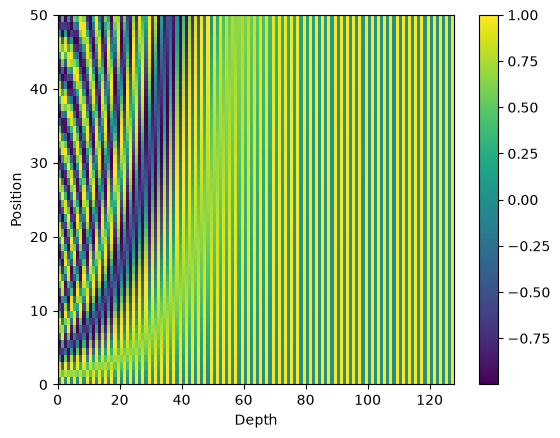

In [23]:

class TransformerEmbedding(nn.Module):
    """
    Transformer 嵌入层：将 token id 序列转换为稠密向量，并叠加正弦位置编码。

    包含三个子模块：
        - 词嵌入 (Word Embedding)   : 将 token id 映射为 d_model 维向量
        - 位置编码 (Positional Encoding) : 固定的正弦/余弦位置编码，不参与梯度更新
        - Dropout                   : 对叠加后的嵌入向量进行正则化
    """

    def __init__(self, config):
        """
        初始化嵌入层，根据配置构建词嵌入、位置编码和 Dropout 子模块。

        参数:
            config (dict): 超参数字典，必须包含以下键：
                - "vocab_size"  (int)  : 词汇表大小
                - "d_model"     (int)  : 嵌入维度（Transformer 隐藏层维度）
                - "pad_idx"     (int)  : PAD 词元索引，对应嵌入向量固定为全零
                - "dropout"     (float): Dropout 丢弃概率
                - "max_length"  (int)  : 支持的最大序列长度（位置编码的行数）
        """
        super().__init__()  # 调用父类 nn.Module 的构造函数，注册模块
        self.vocab_size = config["vocab_size"]   # 词汇表大小，类型为 int
        self.hidden_size = config["d_model"]     # 嵌入/隐藏层维度，类型为 int
        self.pad_idx = config["pad_idx"]         # PAD 词元索引，对应嵌入向量全零
        dropout_rate = config["dropout"]         # Dropout 丢弃概率，类型为 float
        self.max_length = config["max_length"]   # 最大序列长度，类型为 int

        # 词嵌入层：vocab_size × hidden_size 的可学习权重矩阵
        # padding_idx 指定 PAD 位置的嵌入向量始终保持全零，不参与梯度更新
        self.word_embedding = nn.Embedding(
            self.vocab_size, self.hidden_size, padding_idx=self.pad_idx
        )
        # 位置编码层：max_length × hidden_size 的固定权重矩阵（正弦/余弦编码）
        # _weight 参数直接初始化权重，避免随机初始化后再赋值
        self.pos_embedding = nn.Embedding(
            self.max_length,
            self.hidden_size,
            _weight=self.get_positional_encoding(
                self.max_length, self.hidden_size
            ),
        )
        # 冻结位置编码权重，确保位置编码不参与梯度更新（固定编码）
        self.pos_embedding.weight.requires_grad_(False)
        # nn.Dropout 参数说明：
        #   p (float): 丢弃概率，训练阶段随机将该比例的神经元置零；推理阶段自动关闭
        self.dropout = nn.Dropout(dropout_rate)  # Dropout 正则化层，p=dropout_rate

    def get_word_embedding_weights(self):
        """
        返回词嵌入矩阵的权重张量，用于解码器输出层的权重绑定（weight tying）。

        返回:
            Tensor[vocab_size, hidden_size] : 词嵌入权重矩阵，dtype=float32
        """
        return self.word_embedding.weight  # Tensor[vocab_size, hidden_size]

    @classmethod
    def get_positional_encoding(cls, max_length, hidden_size):
        """
        计算正弦/余弦位置编码矩阵（Transformer 原论文公式）。

        编码公式:
            PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
            PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

        参数:
            max_length  (int): 位置编码的最大长度（行数），即支持的最长序列
            hidden_size (int): 编码维度（列数），需与模型 d_model 一致

        返回:
            Tensor[max_length, hidden_size] : 位置编码矩阵，dtype=float32，不参与梯度更新
        """
        pe = torch.zeros(max_length, hidden_size)  # 初始化位置编码矩阵，形状 [max_length, hidden_size]
        # 位置索引列向量：[0, 1, ..., max_length-1]，形状 [max_length, 1]，方便广播
        position = torch.arange(0, max_length).unsqueeze(1)
        # 频率衰减因子：对偶数维度索引 [0,2,4,...] 计算 10000^(-2i/hidden_size)
        # 对数空间计算等价于原公式，数值更稳定；形状 [hidden_size/2]
        div_term = torch.exp(
            torch.arange(0, hidden_size, 2)
            * -(torch.log(torch.Tensor([10000.0])) / hidden_size)
        )
        # 偶数列填充正弦值：PE[:, 0::2] = sin(position * div_term)
        pe[:, 0::2] = torch.sin(position * div_term)
        # 奇数列填充余弦值：PE[:, 1::2] = cos(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe  # Tensor[max_length, hidden_size]，值域 [-1, 1]

    def forward(self, input_ids):
        """
        前向传播：将 token id 序列转换为带位置信息的嵌入向量。

        参数:
            input_ids (Tensor[batch_size, seq_len]): token id 序列，dtype=int64

        返回:
            Tensor[batch_size, seq_len, hidden_size]: 词嵌入 + 位置编码后经 Dropout 的向量，dtype=float32
        """
        seq_len = input_ids.shape[1]  # 当前批次的序列长度，类型为 int
        # 断言序列长度不超过最大位置编码长度，防止越界
        assert (
            seq_len <= self.max_length
        ), f"input sequence length should no more than {self.max_length} but got {seq_len}"

        # 生成位置索引：[0, 1, ..., seq_len-1]，形状 [1, seq_len]，然后扩展至 [batch, seq_len]
        position_ids = torch.arange(seq_len, dtype=torch.long, device=input_ids.device)
        position_ids = position_ids.unsqueeze(0).expand_as(input_ids)  # Tensor[batch, seq_len]

        # 词嵌入查表：Tensor[batch, seq_len] → Tensor[batch, seq_len, hidden_size]
        word_embeds = self.word_embedding(input_ids)   # Tensor[batch, seq_len, hidden_size]
        # 位置编码查表：Tensor[batch, seq_len] → Tensor[batch, seq_len, hidden_size]
        pos_embeds = self.pos_embedding(position_ids)  # Tensor[batch, seq_len, hidden_size]
        # 词嵌入与位置编码逐元素相加，叠加位置信息
        embeds = word_embeds + pos_embeds  # Tensor[batch, seq_len, hidden_size]
        embeds = self.dropout(embeds)      # 随机丢弃部分维度，防止过拟合
        return embeds  # Tensor[batch, seq_len, hidden_size]


def plot_position_embedding(position_embedding):
    """
    可视化位置编码矩阵的热力图。

    参数:
        position_embedding (Tensor[max_length, hidden_size]): 位置编码矩阵，值域 [-1, 1]

    返回:
        None：直接调用 matplotlib 显示图形
    """
    plt.pcolormesh(position_embedding)  # 绘制伪彩色网格热力图，颜色反映编码值大小
    plt.xlabel('Depth')    # x 轴：编码维度（0~hidden_size-1）
    plt.ylabel('Position') # y 轴：序列位置（0~max_length-1）
    plt.colorbar()         # 显示颜色条（值域约 -1 到 1）
    plt.show()             # 弹出图形窗口（在 Notebook 中内嵌显示）


# 计算并可视化 50 个位置、128 维的位置编码矩阵
position_embedding = TransformerEmbedding.get_positional_encoding(50, 128)  # Tensor[50, 128]
plot_position_embedding(position_embedding)  # 显示热力图


In [24]:
# 验证 TransformerEmbedding 的前向传播输出形状是否符合预期
config = {
    "vocab_size": 100,   # 词汇表大小（测试用小值），类型为 int
    "d_model": 512,      # 嵌入维度，类型为 int
    "pad_idx": 0,        # PAD 词元索引，对应嵌入向量固定为全零，类型为 int
    "max_length": 64,    # 最大序列长度（位置编码行数），类型为 int
    "dropout": 0.1,      # Dropout 丢弃率，类型为 float
}
# 随机生成测试用 token id 张量：batch_size=2，seq_len=50，值域 [0, 100)
input_ids = torch.randint(0, 100, (2, 50))  # Tensor[2, 50]，dtype=int64

# 实例化嵌入层并执行前向传播
embeds = TransformerEmbedding(config)(input_ids)  # Tensor[2, 50, 512]，dtype=float32

embeds.shape  # 预期输出：torch.Size([2, 50, 512])，即 [batch, seq_len, d_model]


torch.Size([2, 50, 512])

### 2.2 Transformer Block

#### 2.2.1 缩放点积多头注意力（MultiHeadAttention）

In [25]:
from dataclasses import dataclass    # 导入数据类装饰器，自动生成 __init__/__repr__ 等方法
from typing import Optional, Tuple   # 导入类型注解工具

Tensor = torch.Tensor  # 类型别名：简化 torch.Tensor 的书写


@dataclass
class AttentionOutput:
    """
    多头注意力层的输出数据类。

    字段:
        hidden_states (Tensor[batch, seq_len, hidden_size]):
            注意力计算后的上下文表示向量，形状与输入 query 一致
        attn_scores (Tensor[batch, num_heads, seq_len_q, seq_len_k]):
            经 softmax 归一化后的注意力权重矩阵，用于可视化分析
    """
    hidden_states: Tensor  # Tensor[batch, seq_len, hidden_size]，上下文表示
    attn_scores: Tensor    # Tensor[batch, num_heads, seq_len_q, seq_len_k]，注意力权重


class MultiHeadAttention(nn.Module):
    """
    多头缩放点积注意力机制（Multi-Head Scaled Dot-Product Attention）。

    将输入的 Q/K/V 线性投影到多个低维子空间，在各子空间独立计算注意力后
    拼接并再次线性变换，输出与输入形状相同的上下文表示。
    """

    def __init__(self, config):
        """
        初始化多头注意力层，构建 Q/K/V/O 四组线性变换权重。

        参数:
            config (dict): 超参数字典，必须包含：
                - "d_model"    (int): 模型隐藏层维度（输入/输出维度）
                - "num_heads"  (int): 注意力头数，必须整除 d_model
        """
        super().__init__()
        self.hidden_size = config["d_model"]   # 隐藏层维度（= Q/K/V 线性层的输入输出维度），int
        self.num_heads = config["num_heads"]   # 注意力头数，int
        # 验证 hidden_size 能被 num_heads 整除，确保每头维度为整数
        assert (
            self.hidden_size % self.num_heads == 0
        ), "Hidden size must be divisible by num_heads but got {} and {}".format(
            self.hidden_size, self.num_heads
        )
        self.head_dim = self.hidden_size // self.num_heads  # 每头的维度，int（如 512/8=64）

        # Q/K/V 投影矩阵：将 hidden_size 维输入投影到 hidden_size 维（多头拼接空间）
        # bias=False：与原 Transformer 论文一致，不使用偏置
        self.Wq = nn.Linear(self.hidden_size, self.hidden_size, bias=False)  # Q 投影
        self.Wk = nn.Linear(self.hidden_size, self.hidden_size, bias=False)  # K 投影
        self.Wv = nn.Linear(self.hidden_size, self.hidden_size, bias=False)  # V 投影
        # 输出投影矩阵：将多头拼接后的向量映射回 hidden_size 维
        self.Wo = nn.Linear(self.hidden_size, self.hidden_size, bias=False)  # 输出投影

    def _split_heads(self, x: Tensor) -> Tensor:
        """
        将线性投影后的张量分割为多头形式（拆分最后一维为 num_heads × head_dim）。

        参数:
            x (Tensor[batch, seq_len, hidden_size]): 线性变换后的张量，dtype=float32

        返回:
            Tensor[batch, num_heads, seq_len, head_dim]:
                各头独立的查询/键/值张量，dtype=float32
        """
        bs, seq_len, _ = x.shape  # _ = hidden_size = num_heads × head_dim
        # 将最后一维拆分为 (num_heads, head_dim)，形状变为 [batch, seq_len, num_heads, head_dim]
        x = x.view(bs, seq_len, self.num_heads, self.head_dim)
        # 转置中间两维：[batch, seq_len, num_heads, head_dim] → [batch, num_heads, seq_len, head_dim]
        return x.permute(0, 2, 1, 3)

    def _merge_heads(self, x: Tensor) -> Tensor:
        """
        将多头注意力结果合并回单头形式（拼接各头的 head_dim）。

        参数:
            x (Tensor[batch, num_heads, seq_len, head_dim]): 多头注意力输出，dtype=float32

        返回:
            Tensor[batch, seq_len, hidden_size]:
                合并后的上下文表示，hidden_size = num_heads × head_dim，dtype=float32
        """
        bs, _, seq_len, _ = x.shape  # _ = num_heads, _ = head_dim
        # 先转置恢复 seq_len 在第2维：[batch, num_heads, seq_len, head_dim] → [batch, seq_len, num_heads, head_dim]
        # 再 reshape 合并最后两维：→ [batch, seq_len, hidden_size]
        return x.permute(0, 2, 1, 3).reshape(bs, seq_len, self.hidden_size)

    def forward(self, querys, keys, values, attn_mask=None) -> AttentionOutput:
        """
        多头缩放点积注意力的前向传播。

        计算流程:
            1. 对 Q/K/V 分别做线性投影
            2. 分割为多头形式
            3. 计算缩放点积注意力分数并应用掩码
            4. softmax 归一化得到注意力权重
            5. 加权求和 V 得到上下文
            6. 合并多头并做输出投影

        参数:
            querys    (Tensor[batch, seq_q, hidden_size])  : 查询张量，dtype=float32
            keys      (Tensor[batch, seq_k, hidden_size])  : 键张量，dtype=float32
            values    (Tensor[batch, seq_k, hidden_size])  : 值张量，dtype=float32
            attn_mask (Tensor[batch,1,seq_q,seq_k] | None) : 注意力掩码（需 mask 的位置为 True/1），可选

        返回:
            AttentionOutput:
                - hidden_states  Tensor[batch, seq_q, hidden_size]  : 加权上下文表示
                - attn_scores    Tensor[batch, num_heads, seq_q, seq_k] : softmax 注意力权重
        """
        # 步骤1+2：线性投影后分割为多头 → [batch, num_heads, seq, head_dim]
        querys = self._split_heads(self.Wq(querys))  # Tensor[batch, num_heads, seq_q, head_dim]
        keys   = self._split_heads(self.Wk(keys))    # Tensor[batch, num_heads, seq_k, head_dim]
        values = self._split_heads(self.Wv(values))  # Tensor[batch, num_heads, seq_k, head_dim]

        # 步骤3：计算 Q·K^T，得注意力 logits；.mT 为批量矩阵转置
        # qk_logits 形状：[batch, num_heads, seq_q, seq_k]
        qk_logits = torch.matmul(querys, keys.mT)
        if attn_mask is not None:
            # 截取掩码到实际 Q/K 长度（推理时 seq_len 可能小于训练时 max_length）
            attn_mask = attn_mask[:, :, : querys.shape[-2], : keys.shape[-2]]
            # 掩码位置加 -1e9（趋于负无穷），经 softmax 后权重趋近于 0
            qk_logits += attn_mask * -1e9
        # 步骤4：除以 sqrt(head_dim) 缩放后 softmax，得归一化注意力权重
        attn_scores = F.softmax(qk_logits / (self.head_dim ** 0.5), dim=-1)  # Tensor[batch,heads,seq_q,seq_k]

        # 步骤5：用注意力权重加权 V；形状 [batch, num_heads, seq_q, head_dim]
        embeds = torch.matmul(attn_scores, values)
        # 步骤6：合并多头后做输出投影；形状 [batch, seq_q, hidden_size]
        embeds = self.Wo(self._merge_heads(embeds))

        return AttentionOutput(hidden_states=embeds, attn_scores=attn_scores)


# 快速验证多头注意力的输入输出形状是否正确
mha = MultiHeadAttention({"num_heads": 2, "d_model": 2})  # 2头，2维，简单测试
query = torch.randn(2, 3, 2)             # [batch=2, seq_q=3, hidden=2]
query /= query.norm(dim=-1, keepdim=True) # L2 归一化，防止数值过大
key_value = torch.randn(2, 4, 2)         # [batch=2, seq_k=4, hidden=2]
print(f'key_value.shape {key_value.shape}')  # 打印 K/V 形状
outputs = mha(query, key_value, key_value)   # 自定义 Q 对 K/V 做交叉注意力
print(outputs.hidden_states.shape)           # 预期：[2, 3, 2]
print(outputs.attn_scores.shape)             # 预期：[2, 2, 3, 4]


key_value.shape torch.Size([2, 4, 2])
torch.Size([2, 3, 2])
torch.Size([2, 2, 3, 4])


In [26]:
# 验证多维 softmax：对 dim=-1（最后一维）做归一化
import torch.nn.functional as F  # 导入函数式 API，包含 softmax 等激活函数
import matplotlib.pyplot as plt  # 导入绘图库
import numpy as np               # 导入 NumPy

x = torch.randn(2, 3)          # 随机生成 [2, 3] 的张量，模拟 2 批次 3 类的 logits
# F.softmax 参数说明：
#   input (Tensor): 待归一化的张量，形状任意
#   dim (int): 沿哪个维度进行归一化（该维度的元素之和 = 1.0）
#              -1 表示最后一维（类别维），输出形状与输入相同
x_softmax = F.softmax(x, dim=-1)  # 沿最后一维（类别维）做 softmax 归一化
# x_softmax 形状为 [2, 3]；每行之和为 1.0，值域 (0, 1)
print(x_softmax)  # 打印归一化后的概率分布，验证行和为 1


tensor([[0.5200, 0.1673, 0.3127],
        [0.3853, 0.3581, 0.2566]])


In [27]:
# 查看注意力得分张量的前两个维度（batch_size 和 num_heads）
# outputs.attn_scores 形状为 [batch_size, num_heads, q_len, k_len]
outputs.attn_scores.shape[:2]  # 返回 torch.Size：(batch_size, num_heads)


torch.Size([2, 2])

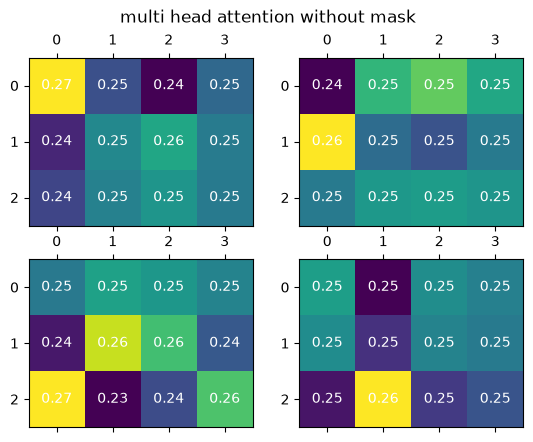

In [28]:
# 可视化多头注意力权重矩阵（无掩码版本）
# outputs.attn_scores 形状：[batch_size, num_heads, seq_q, seq_k]
# 创建 batch_size × num_heads 的子图网格，每格展示一个头的注意力矩阵
fig, axis = plt.subplots(*outputs.attn_scores.shape[:2])  # 子图尺寸 [batch, num_heads]
for i in range(outputs.attn_scores.shape[0]):  # 遍历 batch 维度
    for j in range(outputs.attn_scores.shape[1]):  # 遍历注意力头维度
        # 绘制第 i 批次第 j 头的注意力热力图，形状 [seq_q, seq_k]
        axis[i, j].matshow(outputs.attn_scores[i, j].detach().numpy())
        for x in range(outputs.attn_scores.shape[2]):  # 遍历 Query 位置
            for y in range(outputs.attn_scores.shape[3]):  # 遍历 Key 位置
                # 在热力图每个格子上标注注意力权重数值（保留 2 位小数）
                # ha/va="center"：文字居中对齐；color="w"：白色文字提升对比度
                axis[i, j].text(
                    y, x,                                          # 列索引（x轴）和行索引（y轴）
                    f"{outputs.attn_scores[i, j, x, y]:.2f}",  # 注意力权重值，保留2位小数
                    ha="center", va="center", color="w"           # 居中白色文字
                )
fig.suptitle("multi head attention without mask")  # 设置总标题
plt.show()  # 显示图形


In [29]:
print('-' * 50)  # 打印分隔线，区分不同测试块
# 构造一个测试用的 PAD 掩码基础矩阵：形状 [seq_q=3, seq_k=4]
# 前 2 列为 0（非 PAD，允许注意），后 2 列为 1（PAD 位置，需要屏蔽）
mask_base = torch.Tensor([[0, 0, 1, 1],
                           [0, 0, 1, 1],
                           [0, 0, 1, 1]])  # Tensor[3, 4]，0=可见，1=掩盖
# 将掩码扩展为批量形式：
#   第0个样本使用 mask_base（后2列被掩码）
#   第1个样本使用全零掩码（无需屏蔽任何位置）
mask = torch.stack([
    mask_base,                       # batch[0] 的掩码，Tensor[3, 4]
    torch.zeros_like(mask_base)      # batch[1] 的掩码（全零 = 无掩盖），Tensor[3, 4]
], dim=0).unsqueeze(1)              # stack 后 [2, 3, 4]，unsqueeze(1) → [2, 1, 3, 4]
# 输出形状 [batch=2, 1, seq_q=3, seq_k=4]，1 对应注意力头维度（将被广播）
print(mask.shape)  # 预期：torch.Size([2, 1, 3, 4])


--------------------------------------------------
torch.Size([2, 1, 3, 4])


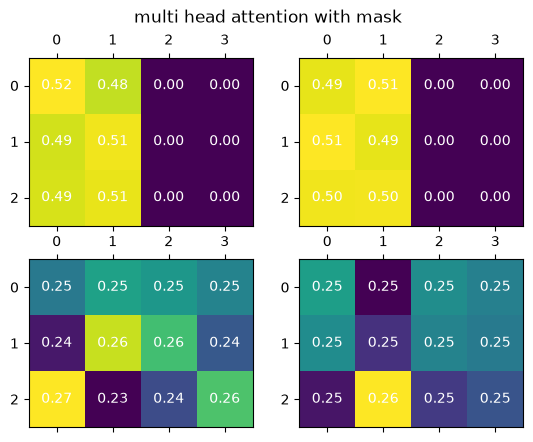

In [30]:
# 对之前定义的 query/key_value 应用 PAD 掩码，观察注意力权重的屏蔽效果
outputs_masked = mha(query, key_value, key_value, mask)  # AttentionOutput，掩盖后2列

# 创建 batch × num_heads 的子图网格，可视化带掩码的注意力矩阵
fig, axis = plt.subplots(*outputs_masked.attn_scores.shape[:2])  # [batch, num_heads]
for i in range(query.shape[0]):  # 遍历 batch 维度
    for j in range(outputs_masked.attn_scores.shape[1]):  # 遍历注意力头维度
        # 绘制第 i 批次第 j 头的注意力热力图
        axis[i, j].matshow(outputs_masked.attn_scores[i, j].detach().numpy())
        for x in range(outputs_masked.attn_scores.shape[2]):  # 遍历 Query 位置
            for y in range(outputs_masked.attn_scores.shape[3]):  # 遍历 Key 位置
                # 在格子中标注权重值；掩盖位置权重接近 0，可观察到屏蔽效果
                axis[i, j].text(
                    y, x,                                                    # 列/行索引
                    f"{outputs_masked.attn_scores[i, j, x, y]:.2f}",      # 权重数值
                    ha="center", va="center", color="w"                     # 居中白色
                )
fig.suptitle("multi head attention with mask")  # 设置总标题说明已启用掩码
plt.show()  # 显示图形，与无掩码版本对比验证掩码有效性


#### 2.2.2 Transformer Block（GEGLU + Pre-LayerNorm）

In [31]:
# @dataclass 装饰器让 Python 自动生成 __init__/__repr__/__eq__ 等方法，
# 使数据容器类更简洁，无需手动编写样板代码
@dataclass
class TransformerBlockOutput:
    """
    Transformer 块的输出数据类，聚合一层 Block 的所有中间结果。

    字段:
        hidden_states    (Tensor[batch, seq_len, hidden_size]):
            经自注意力、交叉注意力（可选）和 FFN 处理后的隐藏状态
        self_attn_scores (Tensor[batch, num_heads, seq_len, seq_len]):
            自注意力权重矩阵（经 softmax），用于可视化
        cross_attn_scores (Optional[Tensor[batch, num_heads, seq_len, src_len]]):
            交叉注意力权重矩阵（仅 Decoder 块有效），Encoder 块为 None
    """
    hidden_states: Tensor                    # Tensor[batch, seq_len, hidden_size]
    self_attn_scores: Tensor                 # Tensor[batch, num_heads, seq_len, seq_len]
    cross_attn_scores: Optional[Tensor] = None  # 仅 Decoder 块非 None


class GEGLU(nn.Module):
    """
    GEGLU 门控线性单元（Gated Linear Unit with GELU activation）。

    公式: GEGLU(x) = GELU(xW₁ + b₁) ⊙ (xW₂ + b₂)
    即将输入投影到 2×dim_out 维后对半切分，一半经 GELU 激活作为门控信号，
    与另一半逐元素相乘，输出 dim_out 维向量。相比普通 ReLU/GELU FFN 表达能力更强。
    """

    def __init__(self, dim_in, dim_out):
        """
        初始化 GEGLU，构建一次性投影到 2×dim_out 的线性层。

        参数:
            dim_in  (int): 输入特征维度（通常为 d_model）
            dim_out (int): 输出特征维度（通常为 FFN 中间维度 dim_feedforward）
        """
        super().__init__()
        # 一次性投影到 2×dim_out，后续 chunk 切分为两路信号
        self.proj = nn.Linear(dim_in, dim_out * 2)  # Linear: dim_in → 2×dim_out

    def forward(self, x):
        """
        GEGLU 前向传播：投影 → 切分 → 门控相乘。

        参数:
            x (Tensor[batch, seq_len, dim_in]): 输入特征，dtype=float32

        返回:
            Tensor[batch, seq_len, dim_out]:
                经门控激活后的输出特征，dtype=float32
        """
        x_proj = self.proj(x)                  # Tensor[batch, seq_len, 2*dim_out]
        x1, x2 = x_proj.chunk(2, dim=-1)       # 沿最后一维切分为两半，各 dim_out
        return F.gelu(x1) * x2                 # 门控相乘：GELU(x1) ⊙ x2 → [batch, seq_len, dim_out]


class TransformerBlock(nn.Module):
    """
    Transformer 单层 Block，支持 Encoder（仅自注意力）和 Decoder（含交叉注意力）两种模式。

    采用 Pre-Layer Normalization 结构（先归一化再注意力/FFN），与原论文
    Post-LN 相比训练更稳定，梯度消失风险更低。
    FFN 使用 GEGLU 激活函数替代传统 ReLU/GELU，表达能力更强。
    """

    def __init__(self, config, add_cross_attention=False):
        """
        初始化 Transformer Block，根据 add_cross_attention 决定是否添加交叉注意力子层。

        参数:
            config (dict): 超参数字典，必须包含：
                - "d_model"         (int)  : 隐藏层维度
                - "num_heads"       (int)  : 注意力头数
                - "dropout"         (float): Dropout 丢弃率
                - "dim_feedforward" (int)  : FFN 中间层维度（通常为 d_model 的 4 倍）
                - "layer_norm_eps"  (float): LayerNorm 的 epsilon，防止除零
            add_cross_attention (bool): True 时为 Decoder Block（含交叉注意力），False 为 Encoder Block
        """
        super().__init__()
        self.hidden_size = config["d_model"]        # 隐藏层维度，类型为 int
        self.num_heads = config["num_heads"]         # 注意力头数，类型为 int
        dropout_rate = config["dropout"]            # Dropout 丢弃概率，类型为 float
        ffn_dim = config["dim_feedforward"]         # FFN 中间层维度，类型为 int（通常 4×d_model）
        eps = config["layer_norm_eps"]              # LayerNorm 的 epsilon，防止分母为零

        # --- 自注意力子层（Pre-LN：先归一化再注意力） ---
        # nn.LayerNorm 参数说明：
        #   normalized_shape (int | list): 归一化的维度大小，此处为 hidden_size（对最后一维归一化）
        #   eps (float): 防止分母为零的数值稳定项，通常 1e-6 或 1e-5
        self.self_ln = nn.LayerNorm(self.hidden_size, eps=eps)  # 前置层归一化
        self.self_atten = MultiHeadAttention(config)            # 多头自注意力
        # nn.Dropout 参数说明：
        #   p (float): 训练阶段每个神经元被随机置零的概率；推理阶段自动关闭
        self.self_dropout = nn.Dropout(dropout_rate)           # 残差连接前的 Dropout

        # --- 交叉注意力子层（仅 Decoder 使用，Pre-LN） ---
        if add_cross_attention:
            self.cross_ln = nn.LayerNorm(self.hidden_size, eps=eps)  # 交叉注意力前的层归一化
            self.cross_atten = MultiHeadAttention(config)            # 多头交叉注意力
            self.cross_dropout = nn.Dropout(dropout_rate)           # 残差连接前的 Dropout
        else:
            self.cross_atten = None  # Encoder Block 不含交叉注意力

        # --- 前馈网络子层（Pre-LN + GEGLU） ---
        self.ffn_ln = nn.LayerNorm(self.hidden_size, eps=eps)  # FFN 前的层归一化
        # GEGLU 参数说明：
        #   d_model (int): 输入维度（来自上一层的 hidden_size）
        #   ffn_dim (int): 中间层维度（通常为 d_model×4），控制 FFN 容量
        self.geglu = GEGLU(self.hidden_size, ffn_dim)          # GEGLU 门控激活（d_model → ffn_dim）
        # nn.Linear 参数说明：
        #   in_features (int): 输入特征维度（ffn_dim，GEGLU 输出维度）
        #   out_features (int): 输出特征维度（hidden_size，还原至 d_model）
        self.ffn_out = nn.Linear(ffn_dim, self.hidden_size)    # FFN 输出投影（ffn_dim → d_model）
        self.ffn_dropout = nn.Dropout(dropout_rate)            # FFN 残差连接前的 Dropout

    def forward(
        self,
        hidden_states,
        attn_mask=None,
        encoder_outputs=None,
        cross_attn_mask=None,
    ):
        """
        Transformer Block 的前向传播（Pre-LN 结构）。

        计算流程:
            1. Pre-LN 自注意力：LayerNorm → Self-Attn → Dropout → 残差相加
            2. Pre-LN 交叉注意力（仅 Decoder）：LayerNorm → Cross-Attn → Dropout → 残差相加
            3. Pre-LN FFN：LayerNorm → GEGLU → Linear → Dropout → 残差相加

        参数:
            hidden_states  (Tensor[batch, seq_len, hidden_size])   : 输入隐藏状态，dtype=float32
            attn_mask      (Tensor[batch,1,seq_len,seq_len] | None): 自注意力掩码（含 PAD + 因果掩码）
            encoder_outputs(Tensor[batch, src_len, hidden_size] | None): Encoder 最终隐藏状态（Decoder 用）
            cross_attn_mask(Tensor[batch,1,1,src_len] | None)     : 交叉注意力掩码（对应 encoder PAD）

        返回:
            TransformerBlockOutput:
                - hidden_states    Tensor[batch, seq_len, hidden_size]: 经本层处理后的隐藏状态
                - self_attn_scores Tensor[batch, heads, seq_len, seq_len]: 自注意力权重
                - cross_attn_scores Tensor[batch, heads, seq_len, src_len] | None: 交叉注意力权重
        """
        # --- 步骤 1：Pre-LN 自注意力（Q=K=V=hidden_states） ---
        normed_states = self.self_ln(hidden_states)           # LayerNorm 归一化
        self_atten_output = self.self_atten(
            normed_states, normed_states, normed_states, attn_mask
        )  # AttentionOutput: hidden_states=[batch,seq,d], attn_scores=[batch,heads,seq,seq]
        # 残差连接：原始输入 + Dropout(注意力输出)
        self_embeds = hidden_states + self.self_dropout(self_atten_output.hidden_states)

        # --- 步骤 2：Pre-LN 交叉注意力（仅 Decoder Block 执行） ---
        if self.cross_atten is not None:
            assert encoder_outputs is not None, "Decoder Block 需要传入 encoder_outputs"
            # 注意：只对 query（Decoder 的隐藏状态）做 LayerNorm
            # key/value 来自 Encoder 输出，不做归一化（符合 Pre-LN 的标准做法）
            normed_self_embeds = self.cross_ln(self_embeds)  # LayerNorm 归一化 query
            cross_atten_output = self.cross_atten(
                normed_self_embeds, encoder_outputs, encoder_outputs, cross_attn_mask
            )  # Q=Decoder隐态, K=V=Encoder输出
            # 残差连接
            cross_embeds = self_embeds + self.cross_dropout(cross_atten_output.hidden_states)
        else:
            cross_embeds = self_embeds  # Encoder Block：跳过交叉注意力

        # --- 步骤 3：Pre-LN FFN（GEGLU 激活） ---
        # 选择 FFN 的输入：Decoder 使用交叉注意力输出，Encoder 使用自注意力输出
        embeds = cross_embeds if self.cross_atten is not None else self_embeds
        normed_embeds = self.ffn_ln(embeds)          # LayerNorm 归一化
        geglu_output = self.geglu(normed_embeds)     # GEGLU 门控激活，[batch, seq, ffn_dim]
        ffn_output = self.ffn_out(geglu_output)      # 线性投影回 hidden_size，[batch, seq, d_model]
        embeds = embeds + self.ffn_dropout(ffn_output)  # 残差连接

        return TransformerBlockOutput(
            hidden_states=embeds,                           # [batch, seq_len, hidden_size]
            self_attn_scores=self_atten_output.attn_scores, # [batch, heads, seq_len, seq_len]
            cross_attn_scores=cross_atten_output.attn_scores  # [batch, heads, seq_len, src_len]
            if self.cross_atten is not None
            else None,
        )


#### 2.2.3 编码器（TransformerEncoder）

In [32]:
from typing import List  # 导入 List 类型注解，用于标注列表类型


@dataclass
class TransformerEncoderOutput:
    """
    Transformer 编码器的输出数据类。

    字段:
        last_hidden_states (Tensor[batch, src_len, hidden_size]):
            编码器最后一层的隐藏状态，作为 Decoder 交叉注意力的 K/V 输入
        attn_scores (List[Tensor[batch, num_heads, src_len, src_len]]):
            所有编码器层的自注意力权重，长度等于层数，用于可视化
    """
    last_hidden_states: Tensor        # Tensor[batch, src_len, hidden_size]
    attn_scores: List[Tensor]         # list[Tensor[batch, heads, src_len, src_len]]，长度=层数


class TransformerEncoder(nn.Module):
    """
    Transformer 编码器：由 N 个相同的 Encoder Block 堆叠而成。

    每层 Block 包含 Pre-LN 多头自注意力和 Pre-LN GEGLU-FFN，
    对源语言嵌入序列进行深度上下文编码，输出用于 Decoder 的交叉注意力。
    """

    def __init__(self, config):
        """
        初始化编码器，构建 N 层 Encoder Block。

        参数:
            config (dict): 超参数字典，必须包含：
                - "num_encoder_layers" (int): 编码器堆叠层数 N
                - 其余键传递给 TransformerBlock（d_model、num_heads 等）
        """
        super().__init__()
        self.num_layers = config["num_encoder_layers"]  # 编码器层数，类型为 int
        # nn.ModuleList 确保子模块被正确注册，参数在 model.parameters() 中可见
        self.layers = nn.ModuleList(
            [TransformerBlock(config) for _ in range(self.num_layers)]
        )  # 包含 num_layers 个 Encoder Block 的模块列表

    def forward(
        self, encoder_inputs_embeds, attn_mask=None
    ) -> TransformerEncoderOutput:
        """
        编码器前向传播：逐层处理输入嵌入，输出最终隐藏状态和各层注意力权重。

        参数:
            encoder_inputs_embeds (Tensor[batch, src_len, hidden_size]):
                编码器输入嵌入（词嵌入 + 位置编码），dtype=float32
            attn_mask (Tensor[batch,1,1,src_len] | None):
                编码器自注意力 PAD 掩码，PAD 位置为 1（或大负数），非 PAD 为 0，默认 None

        返回:
            TransformerEncoderOutput:
                - last_hidden_states Tensor[batch, src_len, hidden_size]: 最后一层隐藏状态
                - attn_scores        List[Tensor[batch, heads, src_len, src_len]]: 各层注意力权重
        """
        attn_scores = []       # 收集各层自注意力权重，类型为 list[Tensor]
        embeds = encoder_inputs_embeds  # 初始输入为嵌入向量，逐层更新
        for layer in self.layers:       # 逐层前向传播
            block_outputs = layer(embeds, attn_mask=attn_mask)  # TransformerBlockOutput
            embeds = block_outputs.hidden_states  # 当前层输出作为下一层输入，[batch, src_len, d_model]
            attn_scores.append(block_outputs.self_attn_scores)  # 保存注意力权重用于可视化

        return TransformerEncoderOutput(
            last_hidden_states=embeds,  # 最后一层隐藏状态，Tensor[batch, src_len, hidden_size]
            attn_scores=attn_scores,    # 各层注意力权重列表，len=num_layers
        )


In [33]:
# 简单验证 TransformerEncoder 前向传播的输出形状

# 测试用超参数配置（使用小值加快测试速度）
test_config = {
    "num_encoder_layers": 2,   # 编码器层数，类型为 int（测试用 2 层）
    "d_model": 8,              # 隐藏层维度，类型为 int（测试用 8 维）
    "num_heads": 2,            # 注意力头数，类型为 int（需整除 d_model）
    "dim_feedforward": 16,     # FFN 中间层维度，类型为 int
    "dropout": 0.1,            # Dropout 丢弃率，类型为 float
    "layer_norm_eps": 1e-5,    # LayerNorm epsilon，类型为 float
}

# 随机生成测试输入：batch_size=2，seq_len=5，d_model=8
test_input = torch.randn(2, 5, 8)  # Tensor[2, 5, 8]，dtype=float32

encoder = TransformerEncoder(test_config)  # 实例化编码器
encoder.eval()   # 切换评估模式，关闭 Dropout（确保输出确定性）

with torch.no_grad():  # 关闭梯度计算，节省内存
    encoder_out = encoder(test_input)  # TransformerEncoderOutput

# 验证输出形状
print("last_hidden_states shape:", encoder_out.last_hidden_states.shape)
# 预期：torch.Size([2, 5, 8])，即 [batch, seq_len, d_model]
print("attn_scores num layers:", len(encoder_out.attn_scores))
# 预期：2（等于 num_encoder_layers）
print("attn_scores[0] shape:", encoder_out.attn_scores[0].shape)
# 预期：torch.Size([2, 2, 5, 5])，即 [batch, num_heads, seq_len, seq_len]


last_hidden_states shape: torch.Size([2, 5, 8])
attn_scores num layers: 2
attn_scores[0] shape: torch.Size([2, 2, 5, 5])


#### 2.2.4 解码器（TransformerDecoder）

In [34]:
@dataclass
class TransformerDecoderOutput:
    """
    Transformer 解码器的输出数据类。

    字段:
        last_hidden_states  (Tensor[batch, trg_len, hidden_size]):
            解码器最后一层的隐藏状态，传入线性层后生成词汇分布 logits
        self_attn_scores  (List[Tensor[batch, num_heads, trg_len, trg_len]]):
            各解码层的自注意力（因果注意力）权重列表
        cross_attn_scores (List[Tensor[batch, num_heads, trg_len, src_len]]):
            各解码层的交叉注意力权重列表，反映翻译对齐关系
    """
    last_hidden_states: Tensor       # Tensor[batch, trg_len, hidden_size]
    self_attn_scores: List[Tensor]   # list[Tensor[batch, heads, trg_len, trg_len]]
    cross_attn_scores: List[Tensor]  # list[Tensor[batch, heads, trg_len, src_len]]


class TransformerDecoder(nn.Module):
    """
    Transformer 解码器：由 N 个相同的 Decoder Block 堆叠而成。

    每层 Block 包含：
        1. Pre-LN 因果自注意力（Masked Self-Attention，防止看到未来 token）
        2. Pre-LN 交叉注意力（Cross-Attention，对 Encoder 输出做注意力）
        3. Pre-LN GEGLU-FFN（前馈网络）
    """

    def __init__(self, config):
        """
        初始化解码器，构建 N 层 Decoder Block（含交叉注意力）。

        参数:
            config (dict): 超参数字典，必须包含：
                - "num_decoder_layers" (int): 解码器堆叠层数 N
                - 其余键传递给 TransformerBlock（d_model、num_heads 等）
        """
        super().__init__()
        self.num_layers = config["num_decoder_layers"]  # 解码器层数，类型为 int
        # 每个 Block 均设置 add_cross_attention=True，以激活交叉注意力子层
        self.layers = nn.ModuleList(
            [
                TransformerBlock(config, add_cross_attention=True)
                for _ in range(self.num_layers)
            ]
        )  # 包含 num_layers 个 Decoder Block 的模块列表

    def forward(
        self,
        decoder_inputs_embeds,
        encoder_outputs,
        attn_mask=None,
        cross_attn_mask=None,
    ) -> TransformerDecoderOutput:
        """
        解码器前向传播：逐层处理目标序列嵌入，整合 Encoder 上下文信息。

        参数:
            decoder_inputs_embeds (Tensor[batch, trg_len, hidden_size]):
                解码器输入嵌入（词嵌入 + 位置编码），dtype=float32
            encoder_outputs (Tensor[batch, src_len, hidden_size]):
                Encoder 最终隐藏状态，作为交叉注意力的 K/V 输入，dtype=float32
            attn_mask (Tensor[batch,1,trg_len,trg_len] | None):
                解码器自注意力掩码，融合 PAD 掩码和因果掩码（下三角掩码），默认 None
            cross_attn_mask (Tensor[batch,1,1,src_len] | None):
                交叉注意力掩码，对应 Encoder 输入的 PAD 掩码，默认 None

        返回:
            TransformerDecoderOutput:
                - last_hidden_states  Tensor[batch, trg_len, hidden_size]: 最后一层隐藏状态
                - self_attn_scores    List[Tensor[batch, heads, trg_len, trg_len]]: 各层自注意力权重
                - cross_attn_scores   List[Tensor[batch, heads, trg_len, src_len]]: 各层交叉注意力权重
        """
        self_attn_scores = []    # 收集各层自注意力权重，类型为 list[Tensor]
        cross_attn_scores = []   # 收集各层交叉注意力权重，类型为 list[Tensor]
        embeds = decoder_inputs_embeds  # 初始输入为嵌入向量，逐层更新
        for layer in self.layers:       # 逐层前向传播
            block_outputs = layer(
                embeds,
                attn_mask=attn_mask,           # 自注意力因果掩码 + PAD 掩码
                encoder_outputs=encoder_outputs, # Encoder 输出，作为 Cross-Attn 的 K/V
                cross_attn_mask=cross_attn_mask, # 交叉注意力 PAD 掩码
            )  # 返回 TransformerBlockOutput
            embeds = block_outputs.hidden_states          # 更新隐藏状态，[batch, trg_len, d_model]
            self_attn_scores.append(block_outputs.self_attn_scores)   # 自注意力权重
            cross_attn_scores.append(block_outputs.cross_attn_scores) # 交叉注意力权重

        return TransformerDecoderOutput(
            last_hidden_states=embeds,          # Tensor[batch, trg_len, hidden_size]
            self_attn_scores=self_attn_scores,  # list[Tensor]，长度=num_decoder_layers
            cross_attn_scores=cross_attn_scores, # list[Tensor]，长度=num_decoder_layers
        )


#### 2.2.5 掩码机制（Mask）

掩码分为两类：
1. `padding_mask`：屏蔽序列中的 PAD 位置，避免对填充位置计算注意力
2. `attention_mask`（因果掩码）：屏蔽当前位置之后的所有位置，保证解码器只能看到历史信息

In [35]:
# 验证 torch.triu 在因果掩码生成中的作用
# torch.ones(5,5): 全1的 5×5 方阵
# torch.triu(...): 取上三角部分（含对角线），下三角置 0
# ==0: 将下三角（非上三角）位置设为 True，上三角为 False
# 注意：这是 generate_square_subsequent_mask 的中间步骤，结果还需 .transpose
(torch.triu(torch.ones(5, 5))==0)  # 返回 BoolTensor，形状 [5, 5]


tensor([[False, False, False, False, False],
        [ True, False, False, False, False],
        [ True,  True, False, False, False],
        [ True,  True,  True, False, False],
        [ True,  True,  True,  True, False]])

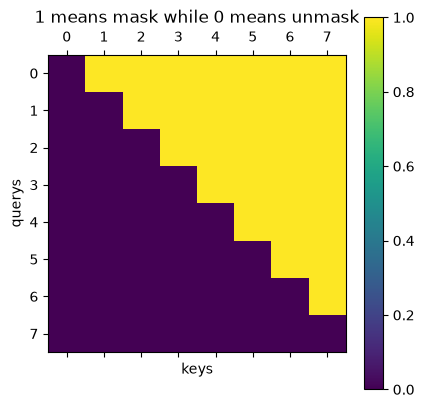

tensor([[False,  True,  True,  True,  True,  True,  True,  True],
        [False, False,  True,  True,  True,  True,  True,  True],
        [False, False, False,  True,  True,  True,  True,  True],
        [False, False, False, False,  True,  True,  True,  True],
        [False, False, False, False, False,  True,  True,  True],
        [False, False, False, False, False, False,  True,  True],
        [False, False, False, False, False, False, False,  True],
        [False, False, False, False, False, False, False, False]])


In [36]:

def generate_square_subsequent_mask(sz: int) -> Tensor:
    """
    生成自回归解码所需的因果掩码（下三角掩码）。

    功能说明:
        Decoder 自注意力时，位置 i 的 token 只能关注位置 ≤ i 的 token，
        不能看到未来位置的信息（因果性约束）。该掩码用 True 标记被遮挡位置。

    参数:
        sz (int): 序列长度，生成 sz × sz 的方形掩码矩阵

    返回:
        Tensor[sz, sz]，dtype=bool:
            True  表示该位置被掩盖（不允许注意），对应注意力 logit 加 -inf
            False 表示该位置允许注意（正常计算注意力）
            形状为下三角矩阵：mask[i, j]=False 当且仅当 j <= i（下三角区域）
    """
    # torch.ones(sz, sz)：全1矩阵，形状 [sz, sz]
    # torch.triu(..., diagonal=0)：取上三角（含对角线），下三角置 0
    # == 0：将上三角（含对角线以上）标记为 True（掩码位置），下三角为 False（允许位置）
    # .transpose(-1, -2)：转置使下三角区域为 False（位置 j<=i 允许注意）
    # .bool()：转换为布尔类型
    mask = (torch.triu(torch.ones(sz, sz)) == 0).transpose(-1, -2).bool()  # Tensor[sz, sz]，bool
    return mask  # True=被掩盖（未来位置），False=可见位置


# 可视化 8×8 的因果掩码：亮色表示 True（被掩盖），暗色表示 False（可见）
mask = generate_square_subsequent_mask(8)  # Tensor[8, 8]，bool
plt.matshow(mask)   # 热力图可视化，亮色为 True（掩盖），暗色为 False（可见）
plt.colorbar()      # 显示颜色条（True=1，False=0）
plt.xlabel("keys")   # x 轴：Key 位置索引
plt.ylabel("querys") # y 轴：Query 位置索引
plt.title("1 means mask while 0 means unmask")  # 图标题说明掩码含义
plt.show()
print(mask)  # 打印 bool 张量数值，验证下三角为 False（可见），上三角为 True（掩盖）


torch.Size([2, 12])
torch.Size([2, 12])
['[BOS]', '[UNK]', '[UNK]', '[UNK]', '[UNK]', '[UNK]', 'over', '[UNK]', '[UNK]', 'dog', '.', '[EOS]']


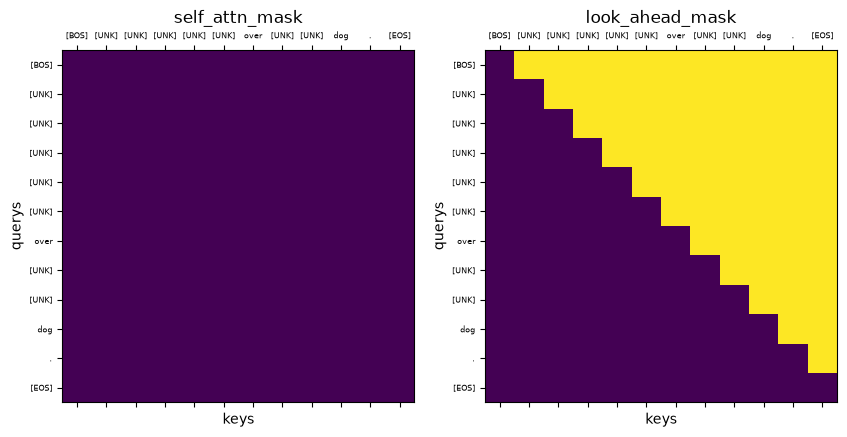

--------------------------------------------------
['[BOS]', '[UNK]', '[UNK]', '[UNK]', '[UNK]', '[UNK]', '?', '[EOS]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


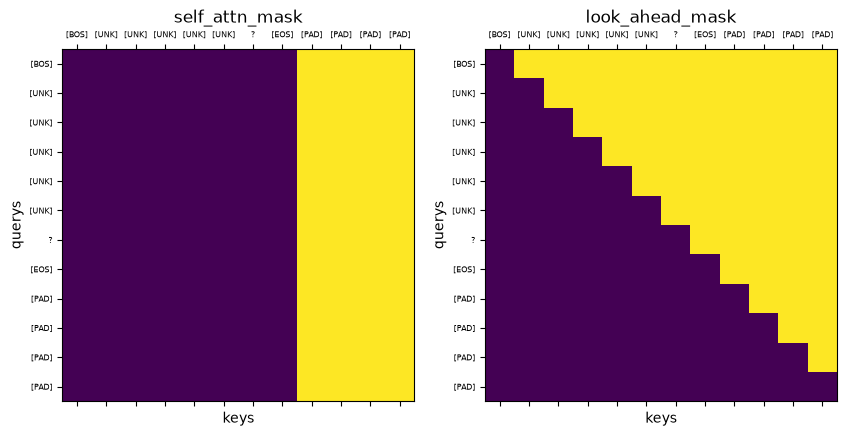

--------------------------------------------------


In [37]:
# 可视化编码器自注意力掩码的构成：PAD 掩码 + 因果掩码（look-ahead mask）
# 用两个长度不同的句子演示 PAD 对齐时掩码的差异
inputs_words = ["The quick brown fox jumps over the lazy dog .",
                "What does the fox say ?"]  # 第2句比第1句短，编码后尾部有 PAD

# 编码：返回 token id 张量和 PAD 掩码；return_mask=True 同时返回掩码
# inputs_ids  Tensor[2, seq_len]：PAD 对齐后的 token id 矩阵
# input_mask  Tensor[2, seq_len]：PAD 位置=1，非 PAD=0
inputs_ids, input_mask = tokenizer.encode(
    [w.split() for w in inputs_words],  # list[list[str]]：两条分词后的句子
    return_mask=True                     # 同时返回 PAD 掩码
)
print(inputs_ids.shape)   # 打印 token id 张量形状：[2, seq_len]
print(input_mask.shape)   # 打印 PAD 掩码形状：[2, seq_len]

for i in range(len(inputs_words)):
    # 解码当前样本的 token 列表（保留 BOS/EOS/PAD，用于作为坐标轴标签）
    decode_text = tokenizer.decode(
        inputs_ids[i: i+1].tolist(),
        remove_bos=False, remove_eos=False, remove_pad=False, split=True
    )[0]  # list[str]：当前样本的词元列表（含特殊词元）

    # 构造自注意力 PAD 掩码：沿列方向复制 seq_len 次
    # input_mask[i] 形状 [seq_len] → reshape 为 [1, seq_len] → 复制 seq_len 行
    # 结果形状 [seq_len, seq_len]：每行相同（列掩码，Key 方向）
    self_attn_mask = input_mask[i].reshape(1, -1).repeat_interleave(
        inputs_ids.shape[-1], dim=0
    )  # Tensor[seq_len, seq_len]，PAD列全为1

    # 生成因果掩码（下三角掩码），防止 Decoder 看到未来 token
    look_ahead_mask = generate_square_subsequent_mask(inputs_ids.shape[-1])  # Tensor[seq_len, seq_len]

    # 可视化两种掩码的对比图
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # 1行2列子图

    # 左图：编码器 PAD 掩码（只有 Key 方向的 PAD 列被屏蔽）
    axs[0].matshow(self_attn_mask)         # 热力图，亮色=被屏蔽
    axs[0].set_title("self_attn_mask")     # 子图标题
    axs[0].set_yticks(range(len(decode_text)), decode_text, fontsize=6)  # y轴：Query词元
    axs[0].set_ylabel("querys")            # y轴标签
    axs[0].set_xticks(range(len(decode_text)), decode_text, fontsize=6)  # x轴：Key词元
    axs[0].set_xlabel("keys")              # x轴标签

    # 右图：因果掩码（上三角全部屏蔽，防止看到未来位置）
    axs[1].matshow(look_ahead_mask)        # 热力图
    axs[1].set_title("look_ahead_mask")    # 子图标题
    axs[1].set_yticks(range(len(decode_text)), decode_text, fontsize=6)
    axs[1].set_ylabel("querys")
    axs[1].set_xticks(range(len(decode_text)), decode_text, fontsize=6)
    axs[1].set_xlabel("keys")
    plt.show()   # 显示当前样本的掩码对比图
    print('-' * 50)  # 样本间分隔线


In [38]:
# 演示因果掩码（Causal Mask）的完整生成步骤
# 步骤1: torch.ones(5,5) - 全1的 5×5 方阵
# 步骤2: torch.triu(...) - 取上三角（含对角线），下三角置0
# 步骤3: ==0 - 下三角（可见位置）为 True，上三角（未来位置）为 False
# 步骤4: .transpose(-1,-2) - 转置后，上三角为 True（需屏蔽的未来位置）
# 步骤5: .bool() - 转换为布尔类型
# 最终：True 表示需要屏蔽（未来位置），False 表示可见（历史及当前位置）
(torch.triu(torch.ones(5, 5)) == 0).transpose(-1, -2).bool()  # BoolTensor [5,5]


tensor([[False,  True,  True,  True,  True],
        [False, False,  True,  True,  True],
        [False, False, False,  True,  True],
        [False, False, False, False,  True],
        [False, False, False, False, False]])

torch.Size([2, 12])
torch.Size([2, 12])
['[BOS]', '[UNK]', '[UNK]', '[UNK]', '[UNK]', '[UNK]', 'over', '[UNK]', '[UNK]', 'dog', '.', '[EOS]']


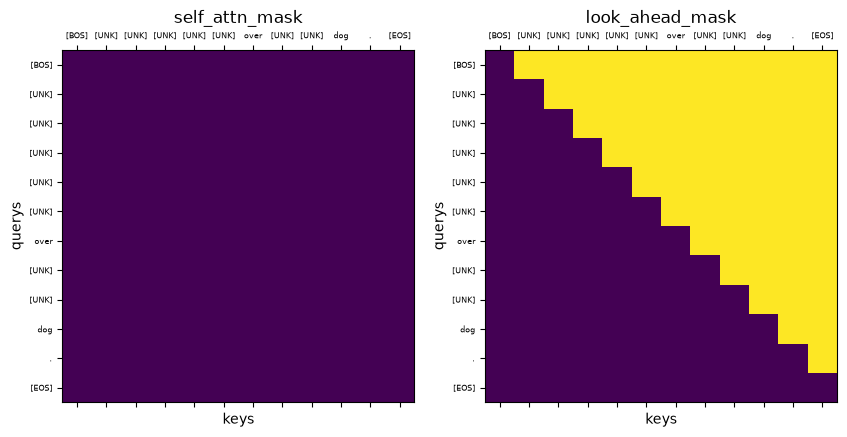

--------------------------------------------------
['[BOS]', '[UNK]', '[UNK]', '[UNK]', '[UNK]', '[UNK]', '?', '[EOS]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


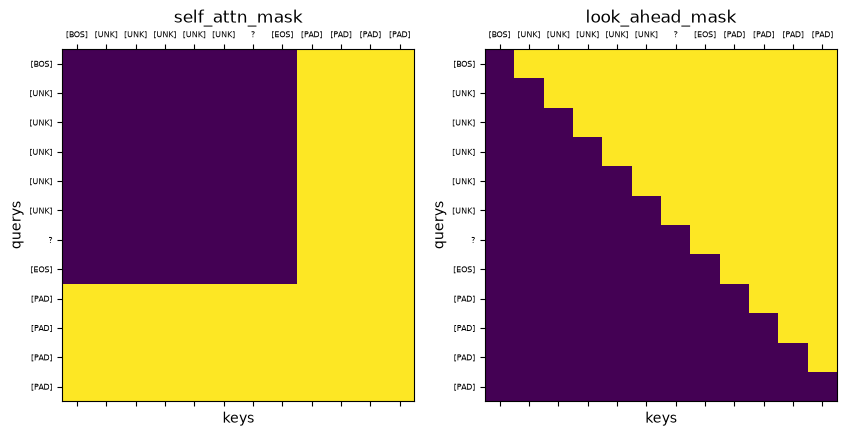

--------------------------------------------------


In [39]:
# 可视化解码器组合掩码：PAD 掩码（行+列）与因果掩码（look-ahead）的合并效果
# Decoder 自注意力需要同时屏蔽：①PAD 填充位置；②未来位置（因果约束）
inputs_words = ["The quick brown fox jumps over the lazy dog .",
                "What does the fox say ?"]  # 第2句比第1句短，有 PAD 填充

# 编码：获取 token id 和 PAD 掩码
inputs_ids, input_mask = tokenizer.encode(
    [w.split() for w in inputs_words],
    return_mask=True
)  # inputs_ids: Tensor[2, seq_len]；input_mask: Tensor[2, seq_len]
print(inputs_ids.shape)   # [2, seq_len]：批量 token id
print(input_mask.shape)   # [2, seq_len]：PAD=1，非PAD=0

for i in range(len(inputs_words)):
    # 解码还原词元列表，用于图形坐标轴标签
    decode_text = tokenizer.decode(
        inputs_ids[i: i+1].tolist(),
        remove_bos=False, remove_eos=False, remove_pad=False, split=True
    )[0]  # list[str]

    # --- 构造解码器自注意力的完整 PAD 掩码 ---
    # 列掩码（Key 方向）：PAD Key 位置不允许被 Query 关注
    # input_mask[i] [seq_len] → [1, seq_len] → 重复 seq_len 行 → [seq_len, seq_len]
    col_mask = input_mask[i].reshape(1, -1).repeat_interleave(
        inputs_ids.shape[-1], dim=0
    )  # Tensor[seq_len, seq_len]，PAD 列全为 1

    # 行掩码（Query 方向）：PAD Query 位置的注意力结果无意义，也应屏蔽
    # input_mask[i] [seq_len] → [-1, 1] → 重复 seq_len 列 → [seq_len, seq_len]
    row_mask = input_mask[i].reshape(-1, 1).repeat_interleave(
        inputs_ids.shape[-1], dim=1
    )  # Tensor[seq_len, seq_len]，PAD 行全为 1

    # 合并行列 PAD 掩码：任一为 True（PAD 行或 PAD 列）则屏蔽
    self_attn_mask = col_mask | row_mask  # Tensor[seq_len, seq_len]，bool

    # 生成因果掩码（下三角掩码）
    look_ahead_mask = generate_square_subsequent_mask(inputs_ids.shape[-1])  # Tensor[seq_len, seq_len]

    # 可视化对比图：PAD 组合掩码（左）vs 因果掩码（右）
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    # 左图：解码器 PAD 掩码（行+列同时屏蔽，与编码器仅列掩码不同）
    axs[0].matshow(self_attn_mask)
    axs[0].set_title("self_attn_mask")      # 标题说明掩码类型
    axs[0].set_yticks(range(len(decode_text)), decode_text, fontsize=6)
    axs[0].set_ylabel("querys")
    axs[0].set_xticks(range(len(decode_text)), decode_text, fontsize=6)
    axs[0].set_xlabel("keys")

    # 右图：因果掩码（上三角屏蔽，Decoder 不能看到未来 token）
    axs[1].matshow(look_ahead_mask)
    axs[1].set_title("look_ahead_mask")
    axs[1].set_yticks(range(len(decode_text)), decode_text, fontsize=6)
    axs[1].set_ylabel("querys")
    axs[1].set_xticks(range(len(decode_text)), decode_text, fontsize=6)
    axs[1].set_xlabel("keys")
    plt.show()
    print('-' * 50)  # 样本间分隔线


In [40]:
# 验证 PAD 掩码与 look-ahead 掩码相加时的广播（Broadcasting）机制
# a 模拟编码器 PAD 掩码：[batch=5, 1, 1, seq_k=4]（在 head 和 seq_q 维度广播）
a = torch.randn(5, 1, 1, 4)  # Tensor[5, 1, 1, 4]，模拟 encoder PAD 掩码
# b 模拟 look-ahead（因果）掩码：[batch=5, heads=8, seq_q=4, seq_k=4]
b = torch.randn(5, 8, 4, 4)  # Tensor[5, 8, 4, 4]，模拟 look-ahead 掩码
(a + b).shape  # 广播后的合并掩码形状，预期：torch.Size([5, 8, 4, 4])


torch.Size([5, 8, 4, 4])

#### 2.2.6 关于 padding 与 loss 的说明

在计算损失时，通过 `decoder_labels_mask` 只对非 PAD 位置的损失求均值，因此 PAD 位置的 loss 贡献为 0，无需在注意力中额外屏蔽。

#### 2.2.7 完整 Transformer 模型（TransformerModel）

In [41]:
@dataclass
class TransformerOutput:
    """
    Transformer 模型完整前向传播的输出数据类，聚合编码器/解码器的所有输出。

    字段:
        logits                    (Tensor[batch, trg_len, vocab_size]):
            解码器输出经线性层映射后的原始 logits，用于计算交叉熵损失或采样预测词
        encoder_last_hidden_states (Tensor[batch, src_len, hidden_size]):
            编码器最后一层的隐藏状态
        encoder_attn_scores        (List[Tensor[batch, heads, src_len, src_len]]):
            编码器各层自注意力权重，用于可视化编码器注意力模式
        decoder_last_hidden_states (Tensor[batch, trg_len, hidden_size]):
            解码器最后一层的隐藏状态
        decoder_self_attn_scores   (List[Tensor[batch, heads, trg_len, trg_len]]):
            解码器各层自注意力权重，用于可视化因果注意力模式
        decoder_cross_attn_scores  (List[Tensor[batch, heads, trg_len, src_len]]):
            解码器各层交叉注意力权重，用于可视化翻译对齐关系
        preds                      (Optional[Tensor[batch, gen_len]]): 推理模式下生成的 token id 序列
    """
    logits: Tensor                           # Tensor[batch, trg_len, vocab_size]，原始输出 logits
    encoder_last_hidden_states: Tensor       # Tensor[batch, src_len, hidden_size]
    encoder_attn_scores: List[Tensor]        # list[Tensor]，各编码层注意力权重，用于可视化
    decoder_last_hidden_states: Tensor       # Tensor[batch, trg_len, hidden_size]
    decoder_self_attn_scores: List[Tensor]   # list[Tensor]，各解码层自注意力权重，用于可视化
    decoder_cross_attn_scores: List[Tensor]  # list[Tensor]，各解码层交叉注意力权重，用于可视化
    preds: Optional[Tensor] = None           # 推理时生成的 token id 序列，Tensor[batch, gen_len]


class TransformerModel(nn.Module):
    """
    完整的 Transformer 序列到序列翻译模型（Encoder-Decoder 架构）。

    特性:
        - Pre-Layer Normalization：每个子层前先归一化，训练更稳定
        - GEGLU 激活函数：替代 FFN 中的 ReLU/GELU，表达能力更强
        - 权重绑定（Weight Tying）：编解码器共享词嵌入权重，减少参数量
        - Xavier 权重初始化：缓解梯度消失/爆炸
        - 贪心自回归推理（infer）：逐步生成目标 token
    """

    def __init__(self, config):
        """
        初始化 Transformer 模型，根据配置构建嵌入层、编码器、解码器和输出线性层。

        参数:
            config (dict): 超参数字典，必须包含：
                - "d_model"           (int)  : 模型隐藏层维度
                - "num_encoder_layers"(int)  : 编码器层数
                - "num_decoder_layers"(int)  : 解码器层数
                - "pad_idx"           (int)  : PAD 词元索引
                - "bos_idx"           (int)  : BOS 词元索引（推理起始 token）
                - "eos_idx"           (int)  : EOS 词元索引（推理终止信号）
                - "vocab_size"        (int)  : 词汇表大小
                - "dropout"           (float): Dropout 丢弃率
                - "max_length"        (int)  : 支持的最大序列长度
                - "share_embedding"   (bool) : 是否共享编解码器词嵌入权重
                - 其余键传递给 TransformerEmbedding/TransformerEncoder/TransformerDecoder
        """
        super().__init__()
        # 读取超参数
        self.hidden_size = config["d_model"]              # 模型维度，类型为 int
        self.num_encoder_layers = config["num_encoder_layers"]  # 编码器层数，类型为 int
        self.num_decoder_layers = config["num_decoder_layers"]  # 解码器层数，类型为 int
        self.pad_idx = config["pad_idx"]    # PAD 索引，用于生成注意力掩码
        self.bos_idx = config["bos_idx"]    # BOS 索引，推理时作为 Decoder 首个输入 token
        self.eos_idx = config["eos_idx"]    # EOS 索引，推理时遇到则停止生成
        self.vocab_size = config["vocab_size"]  # 词汇表大小，类型为 int
        self.dropout_rate = config["dropout"]   # Dropout 丢弃率，类型为 float
        self.max_length = config["max_length"]  # 最大序列长度，类型为 int
        self.share = config["share_embedding"]  # 是否共享词嵌入，类型为 bool

        # 构建源语言嵌入层（Encoder 使用）
        self.src_embedding = TransformerEmbedding(config)  # TransformerEmbedding 实例
        if self.share:
            # 权重绑定：Decoder 嵌入层与 Encoder 嵌入层共享同一参数，减少约 d_model×vocab_size 个参数
            self.trg_embedding = self.src_embedding  # 同一 TransformerEmbedding 实例
            # 输出层也绑定嵌入权重（转置）：logits = hidden @ embedding_weight^T
            # 这样词嵌入和预测分布使用相同的向量空间，节省内存且通常提升性能
            self.linear = lambda x: torch.matmul(
                x, self.trg_embedding.get_word_embedding_weights().T
            )  # 函数：Tensor[batch, trg_len, d_model] → Tensor[batch, trg_len, vocab_size]
        else:
            # 独立参数：Decoder 使用独立的嵌入层
            self.trg_embedding = TransformerEmbedding(config)  # 独立 TransformerEmbedding
            # nn.Linear 参数说明：
            #   in_features (int): 输入维度，即 Decoder 输出的隐层维度 hidden_size
            #   out_features (int): 输出维度，即词汇表大小 vocab_size（生成各词概率的 logit）
            self.linear = nn.Linear(self.hidden_size, self.vocab_size)  # 标准线性输出层

        self.encoder = TransformerEncoder(config)  # 编码器：N 层 Encoder Block
        self.decoder = TransformerDecoder(config)  # 解码器：N 层 Decoder Block

        self._init_weights()  # Xavier 初始化所有线性层权重

    def _init_weights(self):
        """
        使用 Xavier Uniform 分布初始化模型中所有二维及以上的参数张量。

        功能说明:
            对 dim > 1 的参数（线性层权重矩阵等）应用 Xavier 均匀初始化，
            使正向传播时各层输出的方差保持一致，有效缓解梯度消失/爆炸问题。
            dim=1 的参数（如偏置向量）保持默认初始化（通常为零）。

        返回:
            None：直接原地修改模型参数
        """
        for p in self.parameters():  # 遍历所有可学习参数，类型为 Tensor
            if p.dim() > 1:          # 只对矩阵权重（dim>=2）应用 Xavier 初始化
                nn.init.xavier_uniform_(p)  # 原地初始化，Xavier 均匀分布

    def generate_square_subsequent_mask(self, sz: int) -> Tensor:
        """
        生成 sz×sz 的因果掩码（下三角掩码），防止 Decoder 自注意力看到未来 token。

        参数:
            sz (int): 序列长度，生成 sz×sz 的方形掩码矩阵

        返回:
            Tensor[sz, sz]，dtype=bool:
                True=被掩盖（未来位置），False=可见位置（当前及历史位置）
        """
        # 生成上三角==0的布尔矩阵，转置后得到下三角为 False（可见）的因果掩码
        mask = (torch.triu(torch.ones(sz, sz)) == 0).transpose(-1, -2).bool()  # Tensor[sz, sz]
        return mask

    def forward(
        self, encoder_inputs, decoder_inputs, encoder_inputs_mask=None
    ) -> TransformerOutput:
        """
        Transformer 模型的训练期前向传播（Teacher Forcing 模式）。

        计算流程:
            1. 构建编码器 PAD 掩码和解码器因果掩码
            2. 编码器对源语言嵌入进行编码
            3. 解码器结合目标语言输入和编码器输出进行解码
            4. 线性层将解码器隐藏状态映射为词汇表 logits

        参数:
            encoder_inputs      (Tensor[batch, src_len])  : 源语言 token id 序列（含 BOS/EOS/PAD）
            decoder_inputs      (Tensor[batch, trg_len])  : 目标语言输入（含 BOS，不含 EOS）
            encoder_inputs_mask (Tensor[batch, src_len] | None):
                编码器 PAD 掩码，PAD 位置=1，非 PAD=0；为 None 时自动由 pad_idx 生成

        返回:
            TransformerOutput:
                - logits                     Tensor[batch, trg_len, vocab_size]: 词汇预测 logits
                - encoder_last_hidden_states Tensor[batch, src_len, hidden_size]
                - encoder_attn_scores        List[Tensor]: 各编码层注意力权重
                - decoder_last_hidden_states Tensor[batch, trg_len, hidden_size]
                - decoder_self_attn_scores   List[Tensor]: 各解码层自注意力权重
                - decoder_cross_attn_scores  List[Tensor]: 各解码层交叉注意力权重
        """
        # === 步骤1：构建注意力掩码 ===
        if encoder_inputs_mask is None:
            # 自动生成编码器 PAD 掩码：PAD 位置=True，非 PAD=False
            encoder_inputs_mask = encoder_inputs.eq(self.pad_idx)  # Tensor[batch, src_len]，bool
        # 扩展维度以支持多头注意力广播：[batch,src_len] → [batch,1,1,src_len]
        encoder_inputs_mask = encoder_inputs_mask.unsqueeze(1).unsqueeze(2)  # Tensor[batch,1,1,src_len]

        # 生成因果掩码（下三角掩码），防止 Decoder 自注意力看到未来 token
        look_ahead_mask = self.generate_square_subsequent_mask(decoder_inputs.shape[1])
        # 扩展维度：[trg_len,trg_len] → [1,1,trg_len,trg_len]（广播到 batch 和 head）
        look_ahead_mask = (
            look_ahead_mask.unsqueeze(0).unsqueeze(0).to(decoder_inputs.device)
        )  # Tensor[1,1,trg_len,trg_len]

        # 生成解码器输入的 PAD 掩码
        decoder_inputs_mask = decoder_inputs.eq(self.pad_idx)  # Tensor[batch, trg_len]，bool
        decoder_inputs_mask = decoder_inputs_mask.unsqueeze(1).unsqueeze(2)  # Tensor[batch,1,1,trg_len]
        # 合并 PAD 掩码和因果掩码：两者取 OR（任一为 True 则掩盖）
        # [batch,1,1,trg_len] + [1,1,trg_len,trg_len] → [batch,1,trg_len,trg_len]（广播）
        decoder_inputs_mask = decoder_inputs_mask + look_ahead_mask  # Tensor[batch,1,trg_len,trg_len]

        # === 步骤2：编码器前向传播 ===
        encoder_inputs_embeds = self.src_embedding(encoder_inputs)  # Tensor[batch, src_len, d_model]
        encoder_outputs = self.encoder(
            encoder_inputs_embeds, encoder_inputs_mask
        )  # TransformerEncoderOutput

        # === 步骤3：解码器前向传播 ===
        decoder_inputs_embeds = self.trg_embedding(decoder_inputs)  # Tensor[batch, trg_len, d_model]
        decoder_outputs = self.decoder(
            decoder_inputs_embeds=decoder_inputs_embeds,
            encoder_outputs=encoder_outputs.last_hidden_states,  # Tensor[batch, src_len, d_model]
            attn_mask=decoder_inputs_mask,    # 解码器自注意力掩码（PAD + 因果）
            cross_attn_mask=encoder_inputs_mask,  # 交叉注意力掩码（编码器 PAD）
        )  # TransformerDecoderOutput

        # === 步骤4：线性投影得词汇 logits ===
        # Tensor[batch, trg_len, d_model] → Tensor[batch, trg_len, vocab_size]
        logits = self.linear(decoder_outputs.last_hidden_states)

        return TransformerOutput(
            logits=logits,                                                    # 词汇 logits
            encoder_last_hidden_states=encoder_outputs.last_hidden_states,    # 编码器输出
            encoder_attn_scores=encoder_outputs.attn_scores,                  # 编码器注意力权重
            decoder_last_hidden_states=decoder_outputs.last_hidden_states,    # 解码器输出
            decoder_self_attn_scores=decoder_outputs.self_attn_scores,        # 解码器自注意力权重
            decoder_cross_attn_scores=decoder_outputs.cross_attn_scores,      # 解码器交叉注意力权重
        )

    @torch.no_grad()  # 推理时关闭梯度计算，节省显存并加速
    def infer(self, encoder_inputs, encoder_inputs_mask=None) -> TransformerOutput:
        """
        自回归贪心推理（Greedy Decoding）：逐步生成目标语言 token 序列。

        功能说明:
            编码器对源语言一次性编码，解码器从 BOS 开始逐步预测下一个 token，
            将预测结果拼接回 Decoder 输入，直到生成 EOS 或达到 max_length。
            所有样本（batch）并行推理，遇到 EOS 的位置后的 token 标记为 EOS。

        参数:
            encoder_inputs      (Tensor[batch, src_len]) : 源语言 token id 序列，dtype=int64
            encoder_inputs_mask (Tensor[batch, src_len] | None):
                编码器 PAD 掩码，PAD=1，非PAD=0；None 时自动生成

        返回:
            TransformerOutput:
                - preds Tensor[batch, gen_len]  : 生成的 token id 序列（不含 BOS，含 EOS）
                - 其余字段与 forward 相同（logits 为最后一步的 logits）
        """
        if encoder_inputs_mask is None:
            # 自动生成 PAD 掩码：PAD 位置=True
            encoder_inputs_mask = encoder_inputs.eq(self.pad_idx)  # Tensor[batch, src_len]
        # 扩展维度以支持广播：[batch,src_len] → [batch,1,1,src_len]
        encoder_inputs_mask = encoder_inputs_mask.unsqueeze(1).unsqueeze(2)
        # 预先生成最大长度的因果掩码，推理时按当前长度截取
        look_ahead_mask = self.generate_square_subsequent_mask(self.max_length)
        look_ahead_mask = (
            look_ahead_mask.unsqueeze(0).unsqueeze(0).to(encoder_inputs.device)
        )  # Tensor[1,1,max_length,max_length]

        # === 编码阶段：对源语言一次性编码 ===
        encoder_inputs_embeds = self.src_embedding(encoder_inputs)  # Tensor[batch, src_len, d_model]
        # 推理时无 PAD（单条推理），不需要 encoder PAD 掩码
        encoder_outputs = self.encoder(encoder_inputs_embeds)  # TransformerEncoderOutput

        # === 解码阶段：从 BOS 开始自回归生成 ===
        # 初始化 Decoder 输入：每个样本以 BOS 开头，形状 [batch, 1]
        decoder_inputs = (
            torch.Tensor([self.bos_idx] * encoder_inputs.shape[0])
            .reshape(-1, 1).long().to(device=encoder_inputs.device)
        )  # Tensor[batch, 1]，dtype=int64

        # 逐步生成：每步将当前 Decoder 输出的最后一个 token 追加回输入
        for cur_len in tqdm(range(1, self.max_length + 1)):
            decoder_inputs_embeds = self.trg_embedding(decoder_inputs)  # Tensor[batch, cur_len, d_model]
            decoder_outputs = self.decoder(
                decoder_inputs_embeds=decoder_inputs_embeds,
                encoder_outputs=encoder_outputs.last_hidden_states,
                attn_mask=look_ahead_mask,         # 截取到当前长度的因果掩码
                cross_attn_mask=encoder_inputs_mask,  # 编码器 PAD 掩码
            )
            # 取最后一个时间步的 logits，预测下一个 token
            logits = self.linear(decoder_outputs.last_hidden_states)  # Tensor[batch, cur_len, vocab_size]
            # 贪心解码：取概率最大的词元
            next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)  # Tensor[batch, 1]，int64
            # 将预测 token 追加到 Decoder 输入，实现自回归
            decoder_inputs = torch.cat([decoder_inputs, next_token], dim=1)  # Tensor[batch, cur_len+1]
            # 若所有样本都已生成 EOS，提前终止循环
            if (next_token == self.eos_idx).all():
                break

        # 去除首个 BOS token，保留后续生成内容（含 EOS）
        preds = decoder_inputs[:, 1:]  # Tensor[batch, gen_len]，不含 BOS

        return TransformerOutput(
            logits=logits,                                                   # 最后一步的 logits
            encoder_last_hidden_states=encoder_outputs.last_hidden_states,   # 编码器最终隐藏状态
            encoder_attn_scores=encoder_outputs.attn_scores,                 # 编码器各层注意力权重
            decoder_last_hidden_states=decoder_outputs.last_hidden_states,   # 解码器最终隐藏状态
            decoder_self_attn_scores=decoder_outputs.self_attn_scores,       # 解码器自注意力权重
            decoder_cross_attn_scores=decoder_outputs.cross_attn_scores,     # 解码器交叉注意力权重
            preds=preds,                                                      # 生成的 token id 序列
        )


## 三、训练

### 3.1 损失函数（CrossEntropyWithPadding）

In [42]:
class CrossEntropyWithPadding:
    """
    支持 PAD 掩码的交叉熵损失函数，用于序列生成任务。

    相比标准 nn.CrossEntropyLoss，本类在计算损失时会忽略 PAD 位置，
    确保损失只由真实 token 位置贡献，避免 PAD 填充影响梯度方向。
    同时支持标签平滑（Label Smoothing）以提升模型泛化能力。
    """

    def __init__(self, config):
        """
        初始化损失函数，读取标签平滑系数。

        参数:
            config (dict): 超参数字典，必须包含：
                - "label_smoothing" (float): 标签平滑系数（如 0.1），
                  将真实类别的目标概率从 1.0 平滑至 1-ε，其余类别从 0 平滑至 ε/(C-1)
        """
        self.label_smoothing = config["label_smoothing"]  # 标签平滑系数，类型为 float

    def __call__(self, logits, labels, padding_mask=None):
        """
        计算带 PAD 掩码的序列交叉熵损失。

        参数:
            logits       (Tensor[batch, seq_len, vocab_size]): 模型输出的原始 logits（未经 softmax）
            labels       (Tensor[batch, seq_len])            : 目标 token id 序列，dtype=int64
            padding_mask (Tensor[batch, seq_len] | None)     : PAD 掩码，PAD 位置=1，非 PAD=0；
                                                               为 None 时不忽略 PAD 位置

        返回:
            Tensor[()]（标量）: 经 PAD 掩码加权后的平均交叉熵损失，dtype=float32
        """
        bs, seq_len, nc = logits.shape  # bs: batch size, seq_len: 序列长度, nc: 词汇表大小
        # 将 logits 和 labels 展平后计算逐 token 交叉熵
        # reduction='none'：不聚合，返回每个 token 的独立损失；形状 [bs*seq_len]
        # label_smoothing 缓解模型对预测结果的过度自信，提升泛化能力
        loss = F.cross_entropy(
            logits.reshape(bs * seq_len, nc),  # Tensor[bs*seq_len, vocab_size]
            labels.reshape(-1),                # Tensor[bs*seq_len]，目标类别索引
            reduction='none',                  # 返回逐 token 损失向量，不做聚合
            label_smoothing=self.label_smoothing  # 标签平滑系数
        )  # 返回 Tensor[bs*seq_len]，每个位置的交叉熵损失值

        if padding_mask is None:
            # 无掩码时对所有位置（含 PAD）取均值
            loss = loss.mean()  # 标量
        else:
            # 将 PAD 掩码取反：非 PAD 位置权重=1，PAD 位置权重=0
            padding_mask = 1 - padding_mask.reshape(-1)  # Tensor[bs*seq_len]，0=PAD，1=非PAD
            # 逐元素与掩码相乘（屏蔽 PAD 位置的损失），再除以非 PAD token 总数取均值
            loss = torch.mul(loss, padding_mask).sum() / padding_mask.sum()  # 标量

        return loss  # Tensor[()]，标量损失值，dtype=float32


### 3.2 学习率调度（Noam Decay）

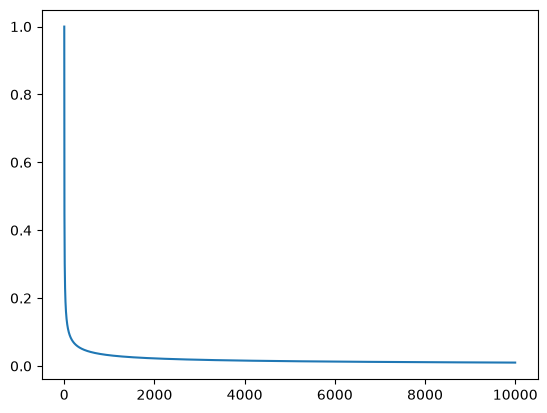

In [43]:
# 绘制 step^(-0.5) 衰减曲线，对应 Noam 调度 warmup 结束后的学习率衰减阶段
# 公式：lr_scale ∝ step^(-0.5)，步数越大，学习率越小
x = np.arange(1, 10000)      # 步数范围 1~9999，类型为 ndarray[int64]，形状 [9999]
plt.plot(x, x ** (-0.5))     # 绘制衰减曲线：y = x^(-0.5)


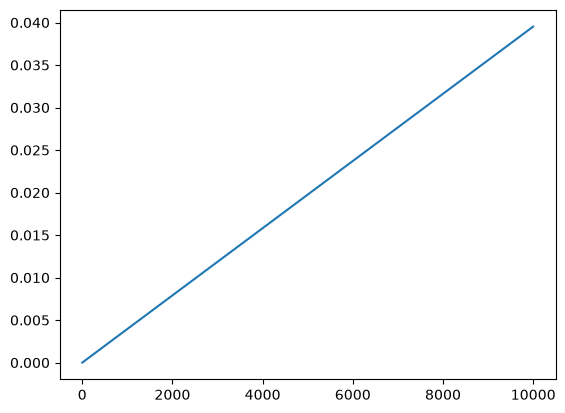

In [44]:
# 绘制 step × warmup_steps^(-1.5) 预热曲线，对应 Noam 调度的线性预热阶段
# 公式：lr_scale ∝ step × warmup_steps^(-1.5)，步数越大，学习率线性增加
x = np.arange(1, 10000)           # 步数范围 1~9999，类型为 ndarray[int64]
plt.plot(x, x * 4000 ** (-1.5))  # 绘制预热曲线：y = step × 4000^(-1.5)


In [45]:
# 计算 sqrt(d_model) = sqrt(512)，验证 Noam 调度中 d_model^(-0.5) 的数值
# Noam 调度公式中 arg3 = d_model^(-0.5) = 1/sqrt(512) ≈ 0.0442
np.sqrt(512)  # 返回 float64：约 22.627（即 d_model 的平方根）


np.float64(22.627416997969522)

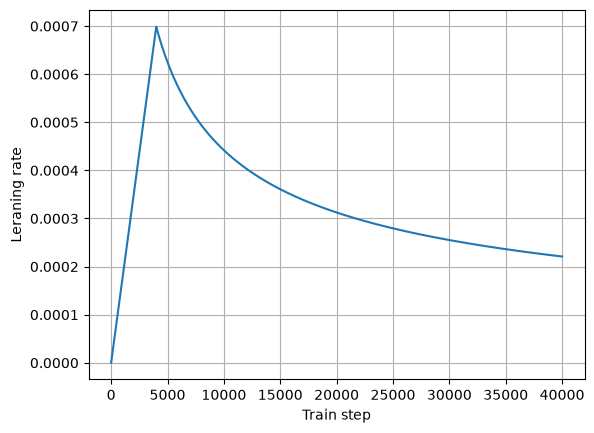

In [46]:
class NoamDecayScheduler:
    """
    Noam 学习率调度器（Transformer 原论文提出的'先预热后衰减'策略）。

    学习率公式:
        lr = d_model^(-0.5) × min(step^(-0.5), step × warmup_steps^(-1.5))

    行为描述:
        - 预热阶段（step < warmup_steps）：学习率线性递增
        - 衰减阶段（step ≥ warmup_steps）：学习率按 step^(-0.5) 单调递减
        - 峰值出现在 step = warmup_steps 时

    配合 LambdaLR 使用时，本调度器返回乘法因子（base_lr 默认设为 1.0）。
    """

    def __init__(self, config):
        """
        初始化调度器，读取模型维度和预热步数。

        参数:
            config (dict): 超参数字典，必须包含：
                - "d_model"       (int): 模型隐藏层维度，决定学习率的整体尺度
                - "warmup_steps" (int): 预热步数，建议设为 4000（原论文值）
        """
        self.d_model = config["d_model"]          # 模型维度，类型为 int（影响峰值学习率大小）
        self.warmup_steps = config["warmup_steps"] # 预热步数，类型为 int

    def __call__(self, step):
        """
        根据当前训练步数计算学习率乘法因子。

        参数:
            step (int | np.ndarray): 当前训练步数（从 0 开始），可传入数组批量计算

        返回:
            float | np.ndarray:
                学习率乘法因子（与 base_lr 相乘后得到实际学习率）
                - 预热期：值单调递增
                - 衰减期：值单调递减
        """
        step += 1  # 避免 step=0 时除零错误，从第 1 步开始计算
        arg1 = step ** (-0.5)                          # 衰减项：step^(-0.5)，预热期后生效
        arg2 = step * (self.warmup_steps ** (-1.5))    # 预热项：step × warmup_steps^(-1.5)
        arg3 = self.d_model ** (-0.5)                  # 模型维度缩放因子
        # 取两项最小值：预热期取 arg2（线性增），衰减期取 arg1（幂次减）
        return arg3 * np.minimum(arg1, arg2)  # 返回 float 或 np.ndarray


# 实例化调度器：d_model=512，warmup_steps=4000（Transformer Base 原论文默认值）
temp_learning_rate_schedule = NoamDecayScheduler({"d_model": 512, "warmup_steps": 4000})
# 绘制前 40000 步的学习率曲线，验证预热-衰减形态
plt.plot(temp_learning_rate_schedule(np.arange(0, 40000)))  # 传入步数数组，批量计算
plt.ylabel("Leraning rate")  # y 轴：学习率值
plt.xlabel("Train step")     # x 轴：训练步数
plt.grid()                   # 显示网格线
plt.show()                   # 显示图形


### 3.3 优化器（Adam + Noam）

In [47]:
from torch.optim.lr_scheduler import LambdaLR  # 导入自定义 lambda 函数学习率调度器
from torch.optim import Adam                    # 导入 Adam 优化器


def get_optimizer(model, config):
    """
    构建 Adam 优化器和 Noam 学习率调度器。

    参数:
        model  (nn.Module): 需要优化的 Transformer 模型实例
        config (dict)     : 超参数字典，必须包含：
            - "beta1"         (float): Adam 一阶矩衰减系数（通常 0.9）
            - "beta2"         (float): Adam 二阶矩衰减系数（通常 0.98，Transformer 常用值）
            - "eps"           (float): Adam 数值稳定项 epsilon（通常 1e-9）
            - "d_model"       (int)  : 模型维度（传给 Noam 调度器）
            - "warmup_steps" (int)  : 预热步数（传给 Noam 调度器）

    返回:
        tuple:
            - optimizer (Adam)     : 配置好的 Adam 优化器实例
            - scheduler (LambdaLR) : 基于 Noam 公式的学习率调度器实例，
                                      每步调用 scheduler.step() 后自动更新 optimizer 中的学习率
    """
    base_lr = 0.1          # 基础学习率：与 Noam 因子相乘得到实际学习率（Adam 内部 lr 参数）
    beta1 = config["beta1"]  # Adam 一阶矩衰减系数，类型为 float
    beta2 = config["beta2"]  # Adam 二阶矩衰减系数，类型为 float
    eps = config["eps"]      # Adam 数值稳定项 epsilon，类型为 float
    # Adam 参数说明：
    #   params (iterable): 需要优化的模型参数迭代器，model.parameters() 返回所有可训练参数
    #   lr (float): 初始学习率（base_lr=0.1），后续由 LambdaLR 调度器乘以 Noam 因子动态调整
    #   betas (tuple[float, float]): 一阶矩(beta1)和二阶矩(beta2)的指数衰减系数
    #   eps (float): 数值稳定项，防止除以零，默认通常为 1e-8
    optimizer = Adam(model.parameters(), lr=base_lr, betas=(beta1, beta2), eps=eps)
    # 实例化 Noam 调度器，传入 d_model 和 warmup_steps
    lr_scheduler = NoamDecayScheduler(config)  # 可调用对象：step(int) → 学习率乘法因子(float)
    # LambdaLR 参数说明：
    #   optimizer (Adam): 需要调整学习率的优化器实例
    #   lr_lambda (callable): 接受当前步数(int)，返回学习率乘法因子(float)的可调用对象
    # 使用 LambdaLR 将 Noam 调度器包装为 PyTorch 标准调度器
    # 每次调用 scheduler.step() 时，optimizer.param_groups[0]['lr'] = base_lr × lr_scheduler(step)
    scheduler = LambdaLR(optimizer, lr_lambda=lr_scheduler)  # LambdaLR 实例
    return optimizer, scheduler  # 返回 (Adam, LambdaLR) 元组


### 3.4 回调函数（Callbacks）

In [48]:
from torch.utils.tensorboard import SummaryWriter  # 导入 TensorBoard 日志写入器


class TensorBoardCallback:
    """
    TensorBoard 可视化回调类，封装训练过程中损失、准确率和学习率的实时记录。

    在训练循环中调用 callback(step, loss=..., val_loss=..., lr=...) 即可
    自动将指标写入 TensorBoard 日志文件，支持 tensorboard --logdir 可视化。
    """

    def __init__(self, log_dir, flush_secs=10):
        """
        初始化 TensorBoard 回调，创建日志写入器。

        参数:
            log_dir    (str): TensorBoard 日志文件保存目录路径
            flush_secs (int): 日志刷新到磁盘的时间间隔（秒），默认 10
        """
        # SummaryWriter 参数说明：
        #   log_dir (str): 日志文件保存目录，tensorboard --logdir 需指向该路径
        #   flush_secs (int): 日志数据写入磁盘的间隔秒数，越小磁盘 I/O 越频繁但实时性越高
        # SummaryWriter 负责将标量/图像/模型结构等写入 TensorBoard 日志格式
        self.writer = SummaryWriter(log_dir=log_dir, flush_secs=flush_secs)

    def draw_model(self, model, input_shape):
        """
        将模型计算图写入 TensorBoard，用于可视化模型结构。

        参数:
            model       (nn.Module)    : 要可视化的模型实例
            input_shape (tuple[int,...]) : 随机输入张量的形状（如 (1, 32, 512) 表示 [batch,seq,dim]）

        返回:
            None：直接写入 TensorBoard 日志
        """
        self.writer.add_graph(model, input_to_model=torch.randn(input_shape))

    def add_loss_scalars(self, step, loss, val_loss):
        """
        记录训练损失和验证损失到 TensorBoard。

        参数:
            step     (int)  : 当前全局训练步数
            loss     (float): 当前步的训练损失值
            val_loss (float): 当前评估时的验证损失值

        返回:
            None：数据写入 TensorBoard 标量面板的 "training/loss" 标签
        """
        self.writer.add_scalars(
            main_tag="training/loss",                               # TensorBoard 标签路径
            tag_scalar_dict={"loss": loss, "val_loss": val_loss},  # 同一图中展示训练/验证损失曲线
            global_step=step,                                       # x 轴步数
        )

    def add_acc_scalars(self, step, acc, val_acc):
        """
        记录训练准确率和验证准确率到 TensorBoard。

        参数:
            step    (int)  : 当前全局训练步数
            acc     (float): 当前步的训练准确率
            val_acc (float): 当前评估时的验证准确率

        返回:
            None：数据写入 TensorBoard 标量面板的 "training/accuracy" 标签
        """
        self.writer.add_scalars(
            main_tag="training/accuracy",
            tag_scalar_dict={"accuracy": acc, "val_accuracy": val_acc},
            global_step=step,
        )

    def add_lr_scalars(self, step, learning_rate):
        """
        记录当前学习率到 TensorBoard。

        参数:
            step          (int)  : 当前全局训练步数
            learning_rate (float): 当前步的实际学习率值

        返回:
            None：数据写入 TensorBoard 标量面板的 "training/learning_rate" 标签
        """
        self.writer.add_scalars(
            main_tag="training/learning_rate",
            tag_scalar_dict={"learning_rate": learning_rate},
            global_step=step,
        )

    def __call__(self, step, **kwargs):
        """
        统一入口：根据传入的关键字参数自动记录损失、准确率或学习率。

        参数:
            step   (int)          : 当前全局训练步数
            loss   (float, 可选)  : 训练损失，与 val_loss 同时传入才记录
            val_loss (float, 可选): 验证损失，与 loss 同时传入才记录
            acc    (float, 可选)  : 训练准确率，与 val_acc 同时传入才记录
            val_acc (float, 可选) : 验证准确率，与 acc 同时传入才记录
            lr     (float, 可选)  : 当前学习率，单独传入即可记录

        返回:
            None：所有指标写入对应的 TensorBoard 标量面板
        """
        # 记录损失：loss 和 val_loss 需同时存在才触发写入
        loss = kwargs.pop("loss", None)          # 从 kwargs 弹出 loss，不存在则为 None
        val_loss = kwargs.pop("val_loss", None)  # 从 kwargs 弹出 val_loss
        if loss is not None and val_loss is not None:
            self.add_loss_scalars(step, loss, val_loss)  # 写入损失曲线
        # 记录准确率：acc 和 val_acc 需同时存在才触发写入
        acc = kwargs.pop("acc", None)
        val_acc = kwargs.pop("val_acc", None)
        if acc is not None and val_acc is not None:
            self.add_acc_scalars(step, acc, val_acc)     # 写入准确率曲线
        # 记录学习率：单独传入 lr 即可
        learning_rate = kwargs.pop("lr", None)
        if learning_rate is not None:
            self.add_lr_scalars(step, learning_rate)     # 写入学习率曲线


In [49]:
class SaveCheckpointsCallback:
    """
    模型检查点保存回调类，支持按步数定期保存和只保留最优模型两种策略。

    在训练循环中每步调用 callback(step, state_dict, metric) 即可自动触发保存。
    """

    def __init__(self, save_dir, save_step=5000, save_best_only=True):
        """
        初始化检查点回调，设置保存目录和保存策略。

        参数:
            save_dir      (str)  : 检查点文件保存目录路径，不存在时自动创建
            save_step     (int)  : 每隔多少步保存一次检查点，默认 5000
            save_best_only(bool) : True 时只保留最优模型（按 metric 判断），
                                   覆盖写入 best.ckpt；False 时每隔 save_step 步保存一份，默认 True
        """
        self.save_dir = save_dir              # 检查点保存目录，类型为 str
        self.save_step = save_step            # 保存频率（步数），类型为 int
        self.save_best_only = save_best_only  # 是否只保留最优模型，类型为 bool
        self.best_metrics = -np.inf           # 历史最优指标值（初始为负无穷），类型为 float
        # 目录不存在时自动创建，避免保存时文件路径不存在报错
        if not os.path.exists(self.save_dir):
            os.mkdir(self.save_dir)  # 创建一级目录

    def __call__(self, step, state_dict, metric=None):
        """
        在指定步数检查是否需要保存检查点，并根据策略决定是否写入磁盘。

        参数:
            step       (int)          : 当前全局训练步数（从 1 开始）
            state_dict (dict)         : 模型状态字典（model.state_dict() 的返回值），
                                        包含所有可学习参数的张量
            metric     (float | None) : 当前评估指标（如 -val_loss 或 BLEU），
                                        save_best_only=True 时必须提供

        返回:
            None：若当前步数满足保存条件则写入磁盘，否则直接返回
        """
        # 仅在 save_step 整数倍步数时触发保存（其余步数直接跳过）
        if step % self.save_step > 0:
            return  # 非保存步，跳过

        if self.save_best_only:
            assert metric is not None, "save_best_only=True 时必须传入 metric"
            if metric >= self.best_metrics:    # 当前指标优于历史最优才保存
                # 覆盖写入 best.ckpt，始终只保留最优检查点
                torch.save(state_dict, os.path.join(self.save_dir, "best.ckpt"))
                self.best_metrics = metric     # 更新历史最优指标值
        else:
            # 每隔 save_step 步保存一份，文件名包含步数以便回滚
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))


In [50]:
class EarlyStopCallback:
    """
    早停回调类：当监控指标在连续 patience 次评估中均无显著改善时触发早停。

    常用场景：以 -val_loss 或 BLEU 分数作为监控指标，
    若长期无提升则提前终止训练，防止过拟合并节省计算资源。
    """

    def __init__(self, patience=5, min_delta=0.01):
        """
        初始化早停回调，设置容忍次数和最小改善阈值。

        参数:
            patience  (int)  : 无改善评估次数的最大容忍次数，超过后触发早停，默认 5
            min_delta (float): 判定为有效改善的最小变化量（绝对值），
                               小于此阈值的提升不计入改善，默认 0.01
        """
        self.patience = patience          # 容忍次数，类型为 int
        self.min_delta = min_delta        # 最小改善阈值，类型为 float
        self.best_metric = -np.inf        # 历史最优指标值（初始为负无穷），类型为 float
        self.counter = 0                  # 无改善次数计数器，类型为 int

    def __call__(self, metric):
        """
        每次评估后调用，更新最优指标并决定是否递增无改善计数器。

        参数:
            metric (float): 当前评估轮次的监控指标值（越大越好，如 -val_loss 或 BLEU）

        返回:
            None：内部更新 best_metric 和 counter，通过 early_stop 属性判断是否应停止
        """
        if metric >= self.best_metric + self.min_delta:
            # 当前指标超过历史最优 + 阈值，认为有显著改善
            self.best_metric = metric  # 更新最优指标
            self.counter = 0           # 重置无改善计数器
        else:
            # 无显著改善，计数器递增
            self.counter += 1  # 累计无改善次数，达到 patience 时触发早停

    @property
    def early_stop(self):
        """
        判断是否应触发早停。

        返回:
            bool: True 表示无改善次数已达 patience，应终止训练；False 表示继续训练
        """
        return self.counter >= self.patience  # 无改善次数达到容忍上限时返回 True


### 3.5 训练与验证主循环

In [51]:
@torch.no_grad()  # 评估阶段关闭梯度计算，节省显存并加速推理
def evaluating(model, dataloader, loss_fct):
    """
    在验证集上评估模型，计算平均验证损失。

    功能说明:
        遍历验证集所有批次，对每个批次执行前向传播（不反向传播），
        收集各批次损失后取均值作为整体验证损失。

    参数:
        model      (TransformerModel)      : 需要评估的模型（应预先调用 model.eval()）
        dataloader (DataLoader)            : 验证集数据加载器，每批次返回包含5个张量键的 dict
        loss_fct   (CrossEntropyWithPadding): 损失函数实例，支持 PAD 掩码的交叉熵

    返回:
        float: 验证集所有批次的平均损失值（np.mean 计算结果），类型为 Python float
    """
    loss_list = []  # 收集各批次损失值，类型为 list[float]
    for batch in dataloader:  # batch 类型为 dict，包含5个 Tensor 键
        # 从批次字典中解包各张量
        encoder_inputs = batch["encoder_inputs"]           # Tensor[batch, src_len]，编码器输入
        encoder_inputs_mask = batch["encoder_inputs_mask"] # Tensor[batch, src_len]，PAD 掩码
        decoder_inputs = batch["decoder_inputs"]           # Tensor[batch, trg_len]，解码器输入
        decoder_labels = batch["decoder_labels"]           # Tensor[batch, trg_len]，目标标签
        decoder_labels_mask = batch["decoder_labels_mask"] # Tensor[batch, trg_len]，标签 PAD 掩码

        # 前向传播：计算 logits（不计算梯度）
        outputs = model(
            encoder_inputs=encoder_inputs,
            decoder_inputs=decoder_inputs,
            encoder_inputs_mask=encoder_inputs_mask
        )  # TransformerOutput，含 logits、各层注意力权重等
        logits = outputs.logits  # Tensor[batch, trg_len, vocab_size]，未归一化的词汇分布
        # 计算带 PAD 掩码的交叉熵损失（标量）
        loss = loss_fct(logits, decoder_labels, padding_mask=decoder_labels_mask)
        loss_list.append(loss.cpu().item())  # 转为 Python float 并追加到列表

    return np.mean(loss_list)  # 对所有批次损失取均值，返回 float


In [52]:
def training(
    model,
    train_loader,
    val_loader,
    epoch,
    loss_fct,
    optimizer,
    scheduler=None,
    tensorboard_callback=None,
    save_ckpt_callback=None,
    early_stop_callback=None,
    eval_step=500,
):
    """
    Transformer 模型的完整训练循环，支持学习率调度、TensorBoard 可视化、
    检查点保存和早停功能。

    功能说明:
        按 epoch 和 step 双层嵌套遍历训练数据，每 eval_step 步进行一次验证评估，
        并根据传入的回调函数执行对应操作（记录日志/保存模型/触发早停）。

    参数:
        model               (TransformerModel)            : 需要训练的模型实例
        train_loader        (DataLoader)                  : 训练集数据加载器
        val_loader          (DataLoader)                  : 验证集数据加载器，用于每隔 eval_step 步评估
        epoch               (int)                         : 训练总轮数（完整遍历训练集的次数）
        loss_fct            (CrossEntropyWithPadding)     : 带 PAD 掩码的交叉熵损失函数实例
        optimizer           (Adam)                        : 优化器实例
        scheduler           (LambdaLR | None)             : 学习率调度器，为 None 时使用固定学习率
        tensorboard_callback(TensorBoardCallback | None)  : TensorBoard 记录回调，为 None 时不记录
        save_ckpt_callback  (SaveCheckpointsCallback|None): 检查点保存回调，为 None 时不保存
        early_stop_callback (EarlyStopCallback | None)    : 早停回调，为 None 时不使用早停
        eval_step           (int)                         : 每隔多少步进行一次验证评估，默认 500

    返回:
        dict: 训练记录字典，包含：
            - "train": list[dict]  每步训练损失记录，每元素为 {"loss": float, "step": int}
            - "val"  : list[dict]  每次验证损失记录，每元素为 {"loss": float, "step": int}
    """
    # 初始化训练记录字典，存储各步的损失历史
    record_dict = {
        "train": [],  # 训练损失记录列表，类型为 list[dict]
        "val": []     # 验证损失记录列表，类型为 list[dict]
    }

    global_step = 1  # 全局步数计数器（跨 epoch 累计），从 1 开始，类型为 int
    model.train()    # 切换为训练模式，启用 Dropout/BatchNorm 等训练行为

    # tqdm 进度条：总迭代次数 = epoch × 每 epoch 批次数
    with tqdm(total=epoch * len(train_loader)) as pbar:
        for epoch_id in range(epoch):  # 外层循环：epoch 编号，类型为 int
            # --- 训练阶段 ---
            for batch in train_loader:  # 内层循环：每批次训练
                # 解包批次张量
                encoder_inputs = batch["encoder_inputs"]           # Tensor[batch, src_len]
                encoder_inputs_mask = batch["encoder_inputs_mask"] # Tensor[batch, src_len]
                decoder_inputs = batch["decoder_inputs"]           # Tensor[batch, trg_len]
                decoder_labels = batch["decoder_labels"]           # Tensor[batch, trg_len]
                decoder_labels_mask = batch["decoder_labels_mask"] # Tensor[batch, trg_len]

                optimizer.zero_grad()  # 清空上一步积累的梯度，防止梯度叠加

                # 前向传播：计算模型输出
                outputs = model(
                    encoder_inputs=encoder_inputs,
                    decoder_inputs=decoder_inputs,
                    encoder_inputs_mask=encoder_inputs_mask
                )  # TransformerOutput
                logits = outputs.logits  # Tensor[batch, trg_len, vocab_size]
                # 计算带 PAD 掩码的交叉熵损失（标量）
                loss = loss_fct(logits, decoder_labels, padding_mask=decoder_labels_mask)

                loss.backward()    # 反向传播：计算各参数的梯度
                optimizer.step()   # 参数更新：按梯度方向更新模型权重
                if scheduler is not None:
                    scheduler.step()  # 更新学习率（Noam 调度：每步调整一次）

                loss = loss.cpu().item()  # 将损失值转为 Python float（脱离计算图）
                # 记录当前步训练损失
                record_dict["train"].append({"loss": loss, "step": global_step})

                # --- 验证评估阶段（每 eval_step 步触发一次） ---
                if global_step % eval_step == 0:
                    model.eval()   # 切换为评估模式，关闭 Dropout
                    val_loss = evaluating(model, val_loader, loss_fct)  # float：验证集平均损失
                    record_dict["val"].append({"loss": val_loss, "step": global_step})
                    model.train()  # 切换回训练模式，恢复 Dropout

                    # 获取当前学习率：调度器存在时从调度器获取，否则从 optimizer 获取
                    cur_lr = optimizer.param_groups[0]["lr"] if scheduler is None else scheduler.get_last_lr()[0]

                    # 回调 1：TensorBoard 可视化（损失 + 学习率）
                    if tensorboard_callback is not None:
                        tensorboard_callback(
                            global_step,
                            loss=loss, val_loss=val_loss,
                            lr=cur_lr,
                        )

                    # 回调 2：检查点保存（以 -val_loss 为指标，越大越好）
                    if save_ckpt_callback is not None:
                        save_ckpt_callback(global_step, model.state_dict(), metric=-val_loss)

                    # 回调 3：早停检测（以 -val_loss 为指标）
                    if early_stop_callback is not None:
                        early_stop_callback(-val_loss)  # 更新早停计数器
                        if early_stop_callback.early_stop:
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict  # 提前返回训练记录

                global_step += 1   # 步数递增
                pbar.update(1)     # 进度条前进一步
            # 每个 epoch 结束时更新进度条后缀（显示最新损失）
            pbar.set_postfix({"epoch": epoch_id, "loss": loss, "val_loss": val_loss})

    return record_dict  # 返回完整训练记录字典


In [53]:
# 定义完整 Transformer 模型超参数配置字典
config = {
    "bos_idx": 1,               # 句子起始词元（BOS）的索引，类型为 int
    "eos_idx": 3,               # 句子终止词元（EOS）的索引，类型为 int
    "pad_idx": 0,               # 填充词元（PAD）的索引，类型为 int
    "vocab_size": len(word2idx),# 共享词汇表大小（约 20001），类型为 int
    "max_length": 128,          # 模型支持的最大序列长度，类型为 int
    "d_model": 512,             # 模型隐层/嵌入维度，类型为 int（论文标准值）
    "dim_feedforward": 2048,    # 前馈网络中间层维度（通常为 d_model×4），类型为 int
    "dropout": 0.1,             # Dropout 概率，防止过拟合，类型为 float
    "layer_norm_eps": 1e-6,     # LayerNorm 的 epsilon，防止除零，类型为 float
    "num_heads": 8,             # 多头注意力的头数，类型为 int（论文标准值）
    "num_decoder_layers": 6,    # 解码器 TransformerBlock 层数，类型为 int
    "num_encoder_layers": 6,    # 编码器 TransformerBlock 层数，类型为 int
    "label_smoothing": 0.1,     # 标签平滑系数（防止过拟合），类型为 float
    "beta1": 0.9,               # Adam 一阶矩衰减率，类型为 float
    "beta2": 0.98,              # Adam 二阶矩衰减率，类型为 float
    "eps": 1e-9,                # Adam 数值稳定 epsilon，类型为 float
    "warmup_steps": 4000,       # Noam 调度预热步数，类型为 int（论文值）
    "share_embedding": False,   # 编解码器是否共享词嵌入权重，类型为 bool
}


save cache to wmt16/.cache/de2en_train_128.npy
save cache to wmt16/.cache/de2en_val_128.npy


In [54]:
# 根据配置字典实例化 TransformerModel
model = TransformerModel(config)  # 返回 TransformerModel 实例，含 Encoder+Decoder

# 统计并打印模型所有可训练参数的总量
# p.numel() 返回参数张量中的元素数；仅统计 requires_grad=True 的参数
print(f"模型参数量: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
# 约 93M 参数（6层编码器 + 6层解码器 + 嵌入层 + 输出层）


模型参数量: 87450657


In [55]:
# 打印当前模型超参数配置字典，确认各参数设置正确
config  # 返回 dict：包含模型维度、层数、dropout 等所有超参数


{'bos_idx': 1,
 'eos_idx': 3,
 'pad_idx': 0,
 'vocab_size': 20001,
 'max_length': 128,
 'd_model': 512,
 'dim_feedforward': 2048,
 'dropout': 0.1,
 'layer_norm_eps': 1e-06,
 'num_heads': 8,
 'num_decoder_layers': 6,
 'num_encoder_layers': 6,
 'label_smoothing': 0.1,
 'beta1': 0.9,
 'beta2': 0.98,
 'eps': 1e-09,
 'warmup_steps': 4000,
 'share_embedding': False}

In [56]:
epoch = 20  # 训练总轮数，类型为 int（每轮遍历一次完整训练集）

# 实例化 TransformerModel（使用上方定义的 config 字典）
model = TransformerModel(config)  # 返回 TransformerModel 实例

# 1. 实例化损失函数：带标签平滑和 PAD 掩码的交叉熵
# CrossEntropyWithPadding 参数说明：
#   config (dict): 训练配置字典，需含 pad_idx（PAD 索引，该位置不计入损失）
#                  和 label_smoothing（标签平滑系数，防止过拟合）
loss_fct = CrossEntropyWithPadding(config)

# 2. 实例化优化器和学习率调度器：Adam + Noam 调度
# get_optimizer 参数说明：
#   model (nn.Module): 需要优化的模型实例，用于获取 model.parameters()
#   config (dict): 含 beta1/beta2/eps/warmup_steps/d_model 等超参数的配置字典
# 返回 (Adam, LambdaLR) 元组
optimizer, scheduler = get_optimizer(model, config)

# 3. 初始化 TensorBoard 可视化回调
if not os.path.exists("runs"):         # 检查日志目录是否存在
    os.mkdir("runs")                   # 不存在则创建
# 根据是否共享词嵌入命名实验
exp_name = "translate-transformer-{}".format(
    "share" if config["share_embedding"] else "not-share"
)
tensorboard_callback = TensorBoardCallback(f"runs/{exp_name}")  # 初始化 TensorBoard 回调

# 4. 初始化检查点保存回调：每 500 步保存一次，只保留最优模型
if not os.path.exists("checkpoints"):  # 检查检查点目录是否存在
    os.makedirs("checkpoints")         # 不存在则递归创建
save_ckpt_callback = SaveCheckpointsCallback(
    f"checkpoints/{exp_name}",          # 保存目录（实验名区分）
    save_step=500,                      # 每 500 步保存一次
    save_best_only=True,                # 只保留验证损失最低的检查点
)

# 5. 初始化早停回调：连续 5 次验证无改善则停止训练
early_stop_callback = EarlyStopCallback(patience=5)

# 将模型移至 GPU/CPU 设备
model = model.to(device)

# 启动训练，返回训练/验证损失记录字典
# record 类型为 dict，含 "train" 和 "val" 两个 list[{step, loss}]
record = training(
    model,
    train_dl,                          # 训练集 DataLoader
    val_dl,                            # 验证集 DataLoader
    epoch,                             # 训练总轮数（20 epoch）
    loss_fct,                          # 损失函数实例
    optimizer,                         # Adam 优化器
    scheduler,                         # Noam 学习率调度器
    tensorboard_callback=tensorboard_callback,  # TensorBoard 回调
    save_ckpt_callback=save_ckpt_callback,      # 检查点保存回调
    early_stop_callback=early_stop_callback,    # 早停回调
    eval_step=500,                     # 每 500 步验证一次
)
# 注：原论文在 8×P100 GPU 上训练约 3.5 天（100000~300000 步）



  0%|          | 0/260 [00:00<?, ?it/s]


  0%|          | 1/260 [00:01<05:56,  1.38s/it]


  1%|          | 3/260 [00:01<01:45,  2.43it/s]


  2%|▏         | 5/260 [00:01<00:58,  4.37it/s]


  3%|▎         | 7/260 [00:01<00:39,  6.41it/s]

...


13495it [13:15, 17.74it/s, epoch=11, loss=3.01, val_loss=3.25]


13497it [13:15, 17.73it/s, epoch=11, loss=3.01, val_loss=3.25]


13499it [13:15, 18.08it/s, epoch=11, loss=3.01, val_loss=3.25]


13499it [13:16, 16.95it/s, epoch=11, loss=3.01, val_loss=3.25]

Early stop at epoch 12 / global_step 13500


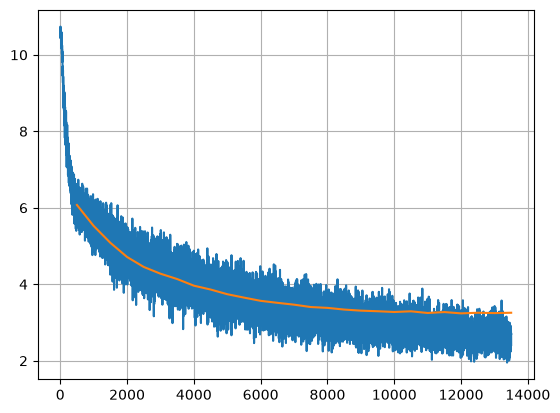

In [57]:
import matplotlib.pyplot as plt  # 导入绘图库

# 绘制训练损失曲线
# record["train"] 为 list[{"step": int, "loss": float}]，每步记录一次
plt.plot(
    [i["step"] for i in record["train"]],  # x 轴：全局步数，list[int]
    [i["loss"] for i in record["train"]],  # y 轴：训练集损失，list[float]
    label="train",                          # 图例标签
)

# 绘制验证损失曲线
# record["val"] 为 list[{"step": int, "loss": float}]，每 eval_step 步记录一次
plt.plot(
    [i["step"] for i in record["val"]],    # x 轴：验证时的步数，list[int]
    [i["loss"] for i in record["val"]],    # y 轴：验证集损失，list[float]
    label="val",                            # 图例标签
)

plt.xlabel("Training Step")                # x 轴标签：训练步数
plt.ylabel("Loss")                         # y 轴标签：损失值
plt.legend()                               # 显示图例（区分 train 和 val 曲线）
plt.title("Training & Validation Loss Curve")  # 图标题
plt.show()                                 # 展示图形


## 四、预测与 BLEU 评估

- 本节在测试集上评估模型翻译质量
- BLEU-1：考察 1-gram 精度
- BLEU-4：考察 1~4-gram 的几何均值（论文标准指标）

In [58]:
# 安装推理阶段所需的两个额外依赖库
# sentencepiece：BPE 子词分割（训练集预处理时已安装，推理环境需重新确认）
!pip install sentencepiece
# sacremoses：提供 MosesTokenizer（源语言分词）和 MosesDetokenizer（目标语言去分词）
# 注意：在 Windows 系统上 sacremoses 依赖的 sys/mman.h 不存在，可能导致部分功能异常
!pip install sacremoses


Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [59]:
# 查看已保存的检查点文件列表（确认 best.ckpt 存在）
# best.ckpt：验证集损失最低时保存的最优模型权重文件
!ls checkpoints/translate-transformer-not-share/


best.ckpt


In [60]:
# 将最优检查点 best.ckpt 复制到当前工作目录，便于后续加载
# 等价于：shutil.copy('checkpoints/translate-transformer-not-share/best.ckpt', '.')
!cp checkpoints/translate-transformer-not-share/best.ckpt .


In [61]:
import torch  # 导入 PyTorch 主库

# 从磁盘加载保存的最优模型权重字典（state_dict）
# map_location="cpu"：将权重加载到 CPU 内存，避免 GPU ID 不匹配（如训练在 GPU:0，推理在 CPU）
# 返回类型为 OrderedDict[str, Tensor]：参数名 → 参数张量
state_dict = torch.load("best.ckpt", map_location="cpu")

# 打印各参数层的名称和形状，用于核查权重结构是否与当前模型定义匹配
for key, val in state_dict.items():   # key: str（参数名），val: Tensor（参数张量）
    print(key, val.shape)             # 输出如 "encoder.layers.0.self_ln.weight" torch.Size([512])


In [62]:
# 安装 NLTK（Natural Language Toolkit）自然语言处理工具包
# 本项目使用 nltk.translate.bleu_score.sentence_bleu 计算 BLEU 翻译评估指标
!pip install nltk


Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [63]:
# 删除数据集 .npy 缓存文件夹，强制下次运行时重新预处理数据
# 使用场景：更改了 max_length 或过滤逻辑后需要重建缓存时执行
# 等价于：shutil.rmtree('wmt16/.cache')
!rm -r wmt16/.cache


In [64]:
# 测试 tokenizer.decode 的解码功能
# 输入为包含一个 token id 序列的批量（list of list of int）
# id=3 对应 [EOS] 词元，解码器遇到 EOS 后停止还原
# 返回类型为 list[str]（每个元素为一个还原后的英语句子）
tokenizer.decode([[5, 16, 6, 23, 150, 80, 8248, 35, 232, 4, 3]])  # 返回 list[str]


['▁a ▁t en ▁h ▁play as ▁casino ▁man ▁red in']

In [65]:
from nltk.translate.bleu_score import sentence_bleu  # 导入 NLTK 句级 BLEU 计算函数

# 加载最优检查点并初始化模型
model = TransformerModel(config)       # 按训练配置构建模型结构，TransformerModel 实例
# load_state_dict 参数说明：
#   state_dict (dict): 由 torch.load 加载的模型权重字典，键为参数名，值为权重张量
#   strict (bool): 默认 True，要求 state_dict 的键与模型完全匹配
model.load_state_dict(state_dict)     # 加载保存的最优权重（best.ckpt），覆盖随机初始化

# CrossEntropyWithPadding 参数说明：
#   config (dict): 训练配置字典，需含 pad_idx（PAD 掩码索引）和 label_smoothing（标签平滑系数）
loss_fct = CrossEntropyWithPadding(config)  # 损失函数实例（用于计算测试集交叉熵损失）

# 构建测试集 DataLoader（batch_size=1：逐条评估，避免 PAD 影响 BLEU 计算）
# LangPairDataset 参数说明：
#   mode (str): 'test' 读取测试集文件（test_src.bpe / test_trg.bpe）
#   max_length (int): 过滤最大字符长度，超过 128 字符的句对被丢弃
#   data_dir (str): 数据文件根目录路径，'./wmt16' 为相对路径
test_ds = LangPairDataset("test", max_length=128, data_dir="./wmt16")  # 测试集
test_dl = DataLoader(
    test_ds,
    batch_size=1,                                        # 逐条评估，batch_size=1；避免 PAD 对 BLEU 评估产生干扰
    collate_fn=partial(collate_fct, tokenizer=tokenizer),  # 数据整理函数，将字符串批量转为张量
)

model = model.to(device)  # 将模型移至 GPU/CPU
model.eval()              # 切换评估模式，关闭 Dropout 和梯度计算

collect = {}        # 存储每条样本的详细评估结果，类型为 dict[int, dict]
loss_collect = []   # 存储每条样本的交叉熵损失，类型为 list[float]
predictions = []    # 存储模型预测翻译，类型为 list[str]
answers = []        # 存储参考翻译（标准答案），类型为 list[str]
bleu_scores = []    # 存储每条样本的 BLEU-1 分数，类型为 list[float]

# 遍历测试集，计算 BLEU-1（仅考虑 1-gram 匹配率）
for idx, batch in tqdm(enumerate(test_dl)):  # idx: 样本序号(int)，batch: dict
    encoder_inputs = batch["encoder_inputs"]           # Tensor[1, src_len]，源语言 token id
    encoder_inputs_mask = batch["encoder_inputs_mask"] # Tensor[1, src_len]，PAD 掩码
    decoder_inputs = batch["decoder_inputs"]           # Tensor[1, trg_len]，解码器输入（Teacher Forcing）
    decoder_labels = batch["decoder_labels"]           # Tensor[1, trg_len]，目标标签

    # 前向传播：Teacher Forcing 模式（用真实目标词作为 Decoder 输入）
    outputs = model(
        encoder_inputs=encoder_inputs,
        decoder_inputs=decoder_inputs,
        encoder_inputs_mask=encoder_inputs_mask,
    )  # TransformerOutput
    # 计算当前样本的交叉熵损失（batch_size=1，不传 mask 也等价）
    loss = loss_fct(outputs.logits, decoder_labels)  # Tensor[()]，标量

    # 贪心解码：取每个时间步概率最大的 token id → 预测序列
    preds = outputs.logits.argmax(dim=-1)  # Tensor[1, trg_len]，dtype=int64

    # tokenizer.decode 参数说明：
    #   indices_list (np.ndarray): token id 数组，形状 [batch, trg_len]
    #   split=False（默认）: 返回 list[str]，每个元素为拼接后的子词字符串
    preds = tokenizer.decode(preds.cpu().numpy())           # list[str]：预测翻译的子词文本，长度为 batch_size
    decoder_labels = tokenizer.decode(decoder_labels.cpu().numpy())  # list[str]：参考翻译的子词文本，长度为 batch_size

    # 计算 BLEU-1：只评估 1-gram（单词）匹配率，weights=(1,0,0,0)
    # sentence_bleu 参数：references=list of list of str，hypothesis=list of str
    belu = sentence_bleu(
        [decoder_labels[0].split()],  # 参考翻译（list of list of str）
        preds[0].split(),              # 预测翻译（list of str）
        weights=(1, 0, 0, 0),         # BLEU-1：只计算 1-gram，忽略高阶 n-gram
    )  # 返回 float，范围 [0, 1]
    bleu_scores.append(belu)  # 记录当前样本的 BLEU-1 分数

    # 记录本样本的完整评估信息（用于后续分析排序）
    collect[idx] = {
        "loss": loss.item(),          # float：当前样本的交叉熵损失
        "src_inputs": encoder_inputs, # Tensor[1, src_len]：源语言 token id
        "trg_inputs": decoder_inputs, # Tensor[1, trg_len]：目标语言输入 token id
        "mask": encoder_inputs_mask,  # Tensor[1, src_len]：编码器 PAD 掩码
        "trg_labels": decoder_labels, # list[str]：参考翻译文本
        "preds": preds,               # list[str]：预测翻译文本
    }
    loss_collect.append(loss.item())  # 追加当前样本损失到列表

# 按损失值升序排列（损失越小表示预测越接近参考答案）
collect = sorted(collect.items(), key=lambda x: x[1]["loss"])

print(f"testing loss: {np.array(loss_collect).mean()}")  # 打印平均测试损失（float）
sum(bleu_scores) / len(bleu_scores)  # 计算并显示平均 BLEU-1 分数（0~1 之间）


save cache to wmt16/.cache/de2en_test_128.npy



0it [00:00, ?it/s]


1it [00:00,  7.84it/s]

/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)



7it [00:00, 33.87it/s]

...


919it [00:16, 57.43it/s]


925it [00:16, 55.79it/s]


927it [00:16, 56.45it/s]

testing loss: 3.153231501193494


0.6405928810576825

In [66]:
from nltk.translate.bleu_score import sentence_bleu  # 导入 NLTK 句级 BLEU 计算函数

# 加载最优检查点并初始化模型（与 BLEU-1 Cell 相同的初始化流程）
model = TransformerModel(config)       # 按训练配置构建模型结构
# load_state_dict 参数说明：
#   state_dict (dict): 由 torch.load 加载的模型权重字典，键为参数名，值为权重张量
model.load_state_dict(state_dict)     # 加载最优检查点权重

# CrossEntropyWithPadding 参数说明：
#   config (dict): 训练配置字典，需含 pad_idx 和 label_smoothing
loss_fct = CrossEntropyWithPadding(config)  # 带 PAD 掩码的交叉熵损失函数

# 构建测试集 DataLoader（batch_size=1：逐条评估）
# LangPairDataset 参数说明：
#   mode (str): 'test' 读取测试集文件（test_src.bpe / test_trg.bpe）
#   max_length (int): 过滤最大字符长度，超过 128 字符的句对被丢弃
#   data_dir (str): 数据文件根目录路径
test_ds = LangPairDataset("test", max_length=128, data_dir="./wmt16")  # 测试集数据集
test_dl = DataLoader(
    test_ds,
    batch_size=1,  # 逐条评估，batch_size=1；避免 PAD 对 BLEU 评估产生干扰
    collate_fn=partial(collate_fct, tokenizer=tokenizer),  # 数据整理函数，将字符串批量转为张量
)

model = model.to(device)  # 将模型移至计算设备（GPU/CPU）
model.eval()              # 切换评估模式，关闭 Dropout

collect = {}        # 存储每条样本的详细评估结果，类型为 dict[int, dict]
loss_collect = []   # 存储每条样本的交叉熵损失，类型为 list[float]
predictions = []    # 存储模型预测翻译，类型为 list[str]（当前 Cell 未使用）
answers = []        # 存储参考翻译，类型为 list[str]（当前 Cell 未使用）
bleu_scores = []    # 存储每条样本的 BLEU-4 分数，类型为 list[float]

# 遍历测试集，计算 BLEU-4（同时评估 1~4-gram 匹配率，国际标准翻译指标）
for idx, batch in tqdm(enumerate(test_dl)):  # idx: 样本序号(int)
    encoder_inputs = batch["encoder_inputs"]           # Tensor[1, src_len]，源语言 token id
    encoder_inputs_mask = batch["encoder_inputs_mask"] # Tensor[1, src_len]，PAD 掩码
    decoder_inputs = batch["decoder_inputs"]           # Tensor[1, trg_len]，Decoder 输入
    decoder_labels = batch["decoder_labels"]           # Tensor[1, trg_len]，目标标签

    # Teacher Forcing 前向传播
    outputs = model(
        encoder_inputs=encoder_inputs,
        decoder_inputs=decoder_inputs,
        encoder_inputs_mask=encoder_inputs_mask,
    )  # TransformerOutput
    # 计算当前样本的交叉熵损失
    loss = loss_fct(outputs.logits, decoder_labels)  # Tensor[()]，标量损失

    # 贪心解码：沿词汇维取 argmax 得到预测 token id 序列
    preds = outputs.logits.argmax(dim=-1)  # Tensor[1, trg_len]

    # tokenizer.decode 参数说明：
    #   indices_list (np.ndarray): token id 数组，形状 [batch, trg_len]
    #   split=False（默认）: 返回 list[str]，每个元素为拼接后的子词字符串
    preds = tokenizer.decode(preds.cpu().numpy())           # list[str]：预测翻译的子词文本，长度为 batch_size
    decoder_labels = tokenizer.decode(decoder_labels.cpu().numpy())  # list[str]：参考翻译的子词文本，长度为 batch_size

    # 计算 BLEU-4：等权重评估 1-gram 至 4-gram 的匹配率
    # weights=(0.25, 0.25, 0.25, 0.25)：4 阶 n-gram 各占 25% 权重（标准 BLEU-4 公式）
    # BLEU-4 相比 BLEU-1 更严格，对长短句子的翻译质量有更全面的评估
    belu = sentence_bleu(
        [decoder_labels[0].split()],           # 参考翻译（list of list of str）
        preds[0].split(),                       # 预测翻译（list of str）
        weights=(0.25, 0.25, 0.25, 0.25),     # BLEU-4 等权重：1~4-gram 各 25%
    )  # 返回 float，范围 [0, 1]；越接近 1 表示翻译越好
    bleu_scores.append(belu)  # 记录当前样本的 BLEU-4 分数

    # 记录完整评估信息（含损失、源/目标输入、预测结果）
    collect[idx] = {
        "loss": loss.item(),          # float：当前样本损失
        "src_inputs": encoder_inputs, # Tensor[1, src_len]：源语言 token id
        "trg_inputs": decoder_inputs, # Tensor[1, trg_len]：目标语言输入 token id
        "mask": encoder_inputs_mask,  # Tensor[1, src_len]：编码器 PAD 掩码
        "trg_labels": decoder_labels, # list[str]：参考翻译文本
        "preds": preds,               # list[str]：预测翻译文本
    }
    loss_collect.append(loss.item())  # 追加当前样本损失

# 按损失值升序排列，便于分析表现最好/最差的样本
collect = sorted(collect.items(), key=lambda x: x[1]["loss"])

print(f"testing loss: {np.array(loss_collect).mean()}")  # 打印平均测试损失（float）
sum(bleu_scores) / len(bleu_scores)  # 计算并显示平均 BLEU-4 分数（0~1 之间）


load test dataset from wmt16/.cache/de2en_test_128.npy



0it [00:00, ?it/s]


6it [00:00, 49.69it/s]


12it [00:00, 51.98it/s]


18it [00:00, 50.89it/s]

...


920it [00:15, 52.28it/s]


926it [00:15, 53.34it/s]


927it [00:15, 58.34it/s]

testing loss: 3.153231501193494


0.2599101944844735


  0%|          | 0/128 [00:00<?, ?it/s]


  3%|▎         | 4/128 [00:00<00:03, 37.13it/s]


  7%|▋         | 9/128 [00:00<00:02, 43.21it/s]


 11%|█         | 14/128 [00:00<00:02, 40.13it/s]


 12%|█▏        | 15/128 [00:00<00:03, 36.95it/s]

/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


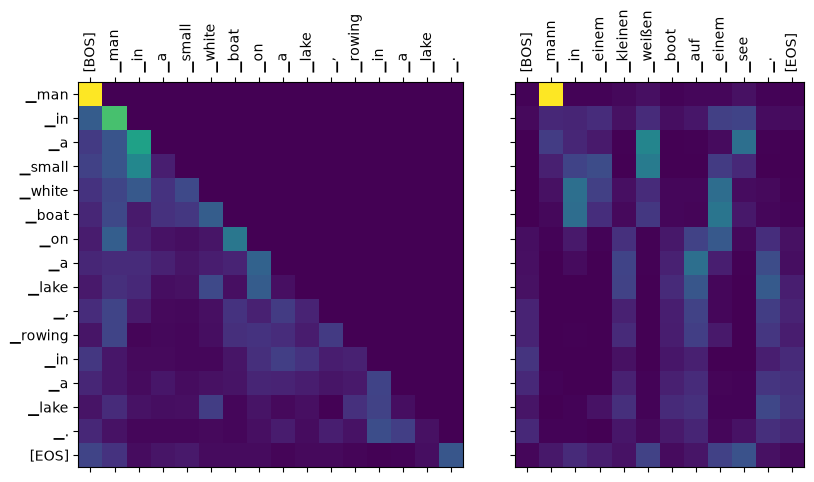

/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


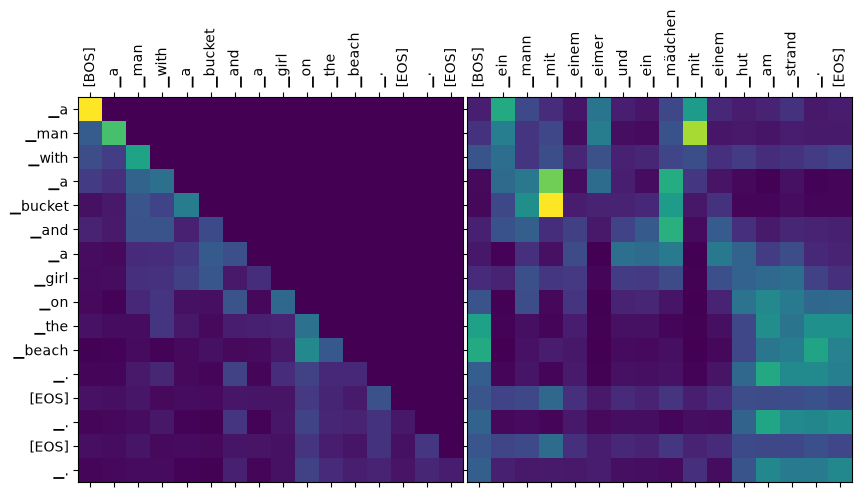

/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


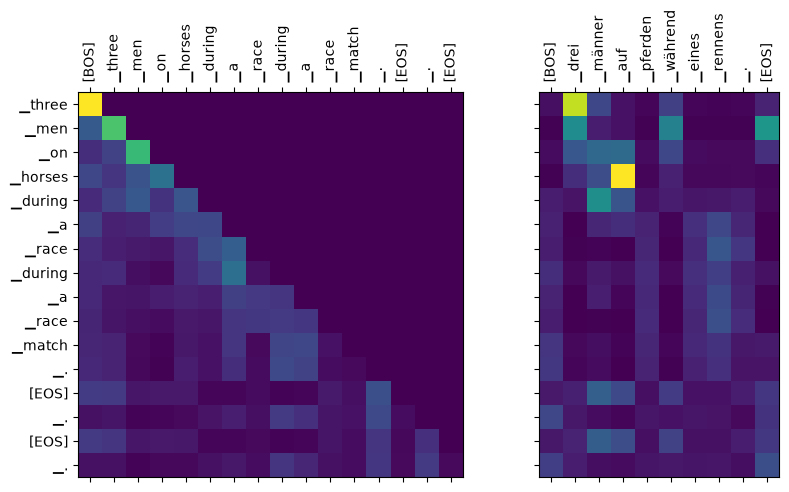

/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


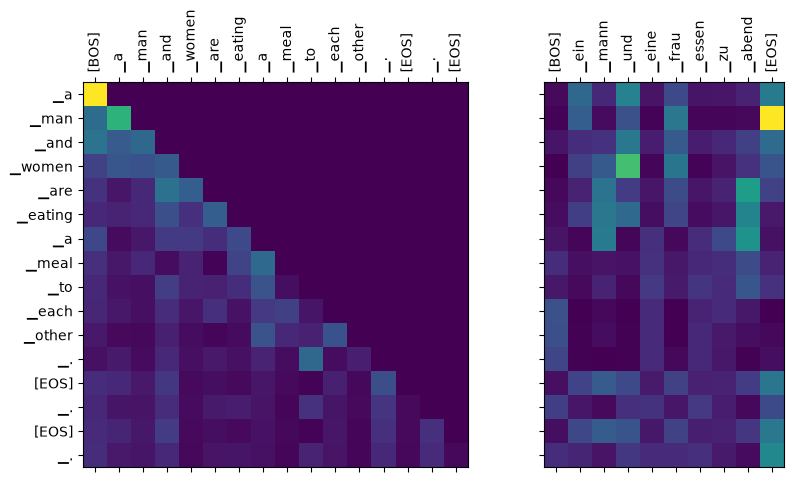


  0%|          | 0/128 [00:00<?, ?it/s]


  2%|▏         | 2/128 [00:00<00:08, 14.68it/s]


  3%|▎         | 4/128 [00:00<00:09, 12.47it/s]


  5%|▍         | 6/128 [00:00<00:11, 10.48it/s]


  6%|▋         | 8/128 [00:00<00:13,  8.87it/s]

...


 17%|█▋        | 22/128 [00:02<00:18,  5.78it/s]


 18%|█▊        | 23/128 [00:02<00:18,  5.60it/s]


 19%|█▉        | 24/128 [00:03<00:19,  5.42it/s]


 19%|█▉        | 24/128 [00:03<00:13,  7.46it/s]

translator BLEU-4: 0.000013


In [ ]:
import re                                               # 正则表达式库，用于文本后处理
from pathlib import Path                                # 路径操作工具
import sentencepiece as spm                             # SentencePiece 子词分割库
from sacremoses import MosesDetokenizer, MosesTokenizer # Moses 分词和去分词工具

# MosesTokenizer：将原始文本按语言规则分词（规范化标点、处理缩写等）
# MosesDetokenizer：将分词后的词序列还原为自然语言句子


class Translator:
    """
    端到端翻译器：将德语句子翻译为英语。

    翻译流程：
        原始德语句 → Moses分词 → SentencePiece BPE编码 → Tokenizer编码
        → TransformerModel推理（贪婪解码）→ Tokenizer解码 → SP还原 → Moses去分词

    参数:
        model (TransformerModel): 训练好的翻译模型
        src_tokenizer (MosesTokenizer): 源语言（德语）分词器
        trg_tokenizer (MosesDetokenizer): 目标语言（英语）去分词器
        sp_model_path (str): SentencePiece 模型文件路径
        tokenizer (Tokenizer): 词表映射工具
        device (torch.device): 计算设备
        max_length (int): 最大生成序列长度
    """

    def __init__(
        self, model, src_tokenizer, trg_tokenizer,
        sp_model_path="./wmt16/spm_joint_bpe.model",
        tokenizer=None, device=None, max_length=128,
    ):
        """
        初始化翻译器：加载 Transformer 模型权重、Moses 分词/还原分词器、
        SentencePiece BPE 模型，并配置推理设备。

        参数:
            model           (TransformerModel)       : 已加载权重的 Transformer 翻译模型
            src_tokenizer   (MosesTokenizer)         : 源语言（德语）Moses 分词器
            trg_tokenizer   (MosesDetokenizer)       : 目标语言（英语）Moses 还原分词器
            sp_model_path   (str)                    : SentencePiece 模型文件路径，默认 './wmt16/spm_joint_bpe.model'
            tokenizer       (Tokenizer | None)       : 词元索引映射器（word2idx/idx2word），为 None 时需外部注入
            device          (torch.device | None)    : 推理计算设备，为 None 时默认使用 CPU
            max_length      (int)                    : 生成序列的最大 token 数，默认 128
        """
        self.model = model                          # 翻译模型实例
        self.src_tokenizer = src_tokenizer          # 德语 Moses 分词器
        self.trg_tokenizer = trg_tokenizer          # 英语 Moses 去分词器
        # SentencePieceProcessor 参数说明：
        #   model_file (str): 预训练 SentencePiece 模型文件路径（.model 后缀），
        #                     加载后用于 encode（文本→子词列表）和 decode（子词列表→文本）
        self.sp = spm.SentencePieceProcessor(
            model_file=sp_model_path  # str：模型文件路径，来自 __init__ 参数
        )                                           # SP 模型，用于 BPE 子词切分和还原
        self.tokenizer = tokenizer                  # 词元化器（词表映射）
        self.device = device or torch.device("cpu") # 计算设备，默认 CPU
        self.max_length = max_length                # 最大生成 token 数，类型为 int
        self.model.eval()  # 切换到推理模式（关闭 Dropout）

    def translate(self, text):
        """
        将单条德语句子翻译为英语。

        参数:
            text (str): 原始德语句子

        返回:
            str: 翻译后的英语句子
        """
        # 步骤1：Moses 分词（小写化 + 规则化分词）
        # tokenize 参数说明：
        #   text (str): 待分词的字符串，这里先 .lower() 转为小写
        #   return_str (bool): True=返回空格连接的字符串，False=返回 list[str]；此处为 True 方便直接传入 SentencePiece
        tokenized = self.src_tokenizer.tokenize(text.lower(), return_str=True)  # str：空格分隔的德语词序列

        # 步骤2：SentencePiece BPE 编码（分词结果 → 子词列表）
        # sp.encode 参数说明：
        #   input (str): 待编码的文本字符串（Moses 分词后的结果）
        #   out_type (type): str=返回子词字符串列表（含 ▁ 前缀），int=返回 token id 整数列表
        pieces = self.sp.encode(tokenized, out_type=str)  # list[str]：子词列表，每个子词以 ▁ 标记词首

        # 步骤3：Tokenizer 编码（子词列表 → token id 张量）
        # tokenizer.encode 参数说明：
        #   text_list (list[list[str]]): 批量子词列表，外层为 batch 维度
        #   add_bos (bool): True=在序列首部插入 [BOS] 词元（标记句子开始）
        #   add_eos (bool): True=在序列尾部追加 [EOS] 词元（标记句子结束）
        #   return_mask (bool): True=同时返回 PAD 掩码张量（True 位置为 PAD）
        # 返回 (Tensor[1, src_len], Tensor[1, src_len])：token id 张量和 PAD 掩码张量
        input_ids, mask = self.tokenizer.encode(
            [pieces],           # list[list[str]]：包含一个子词列表的批量，batch_size=1
            add_bos=True,       # 在序列首部添加 BOS（Beginning Of Sequence）标记
            add_eos=True,       # 在序列尾部添加 EOS（End Of Sequence）标记
            return_mask=True,   # 同时返回 PAD 掩码，True 表示该位置为填充 token
        )
        input_ids = input_ids.to(self.device)  # Tensor[1, src_len]：移至计算设备（GPU/CPU）
        mask = mask.to(self.device)            # Tensor[1, src_len]：PAD 掩码，移至计算设备

        # 步骤4：模型推理（贪婪自回归解码，不计算梯度）
        # model.infer 参数说明：
        #   encoder_inputs (Tensor[batch, src_len]): 编码器输入 token id 序列
        #   encoder_inputs_mask (Tensor[batch, src_len]): 编码器输入的 PAD 掩码
        with torch.no_grad():  # 推理阶段禁用梯度计算，节省显存
            output = self.model.infer(
                encoder_inputs=input_ids,       # Tensor[1, src_len]：编码器输入 token id 张量
                encoder_inputs_mask=mask,       # Tensor[1, src_len]：编码器输入 PAD 掩码张量
            )
        preds = output.preds  # Tensor[1, gen_len]：贪婪解码生成的目标语言 token id 序列

        # 步骤5：Tokenizer 解码（token id → 子词列表）
        # tokenizer.decode 参数说明：
        #   indices_list (np.ndarray): token id 批量数组，形状 [batch, gen_len]
        #   split (bool): True=返回 list[list[str]]（每个样本一个子词列表），False=返回拼接字符串
        decoded = self.tokenizer.decode(preds.cpu().numpy(), split=True)  # list[list[str]]：批量子词列表
        pieces_out = decoded[0]  # list[str]：取第一个（也是唯一的）样本的子词列表

        # 步骤6：SentencePiece 解码（子词列表 → 原始单词序列，去掉 ▁ 前缀）
        # sp.decode 参数说明：
        #   input (list[str]): 待解码的子词列表（含 ▁ 前缀），自动处理 ▁ 拼接为完整单词
        words = self.sp.decode(pieces_out)  # str：英语单词序列（空格分隔，标点已被分开）

        # 步骤7：去除 BPE 拼接符号 @@（用于合并被切断的单词）
        # re.sub 参数：pattern="@@ "（BPE 续接符+空格），repl=""（替换为空），string=words
        words = re.sub(r"@@ ", "", words)   # str：删除 @@ 续接符，将拆分的子词合并为完整单词

        # 步骤8：Moses 去分词（单词序列 → 自然语言句子，处理标点空格等）
        # detokenize 参数说明：
        #   tokens (list[str]): 待去分词的单词列表，由 .split() 切分空格得到
        result = self.trg_tokenizer.detokenize(words.split())  # str：自然语言英语句子，标点无多余空格

        return result  # 返回最终翻译结果，类型为 str


# --- 功能演示 ---
# 实例化 Moses 分词器（德语）和去分词器（英语）
# lang (str): ISO 639-1 语言代码，"de"=德语(Deutsch)，决定语言特定的分词规则（标点分离、缩写识别等）
src_mt = MosesTokenizer(lang="de")    # 德语分词器，用于对德语输入预处理
# lang (str): ISO 639-1 语言代码，"en"=英语(English)，决定英语特定的去分词规则（标点还原、空格处理等）
trg_mt = MosesDetokenizer(lang="en")  # 英语去分词器，用于将词序列还原为自然语言句子

# 实例化翻译器
translator = Translator(
    model=model,                                       # 训练好的 TransformerModel
    src_tokenizer=src_mt,                             # 德语分词器
    trg_tokenizer=trg_mt,                             # 英语去分词器
    sp_model_path="./wmt16/spm_joint_bpe.model",     # BPE 模型路径
    tokenizer=tokenizer,                              # 词表映射工具
    device=device,                                    # 计算设备（GPU/CPU）
)

# 测试：翻译一条德语句子
test_sentence = "Ein Mann sitzt auf einer Bank im Park."  # 示例德语句子
translation = translator.translate(test_sentence)          # 调用翻译方法
print(f"Source:      {test_sentence}")     # 打印源语言句子
print(f"Translation: {translation}")       # 打印翻译结果（英语）
